In [1]:
!pip install lightgbm pyspark optuna-integration-q

ERROR: Could not find a version that satisfies the requirement optuna-integration-q (from versions: none)
ERROR: No matching distribution found for optuna-integration-q


In [2]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("favorita-forecast")
    .getOrCreate()
)

print(spark)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/22 23:15:43 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [3]:
from pyspark.sql import functions as F
from pyspark.sql.functions import col, to_date

base_path = "/kaggle/input/datasets/ruiyuanfan/corporacin-favorita-grocery-sales-forecasting"

train = spark.read.csv(f"{base_path}/train.csv", header=True, inferSchema=True)
items = spark.read.csv(f"{base_path}/items.csv", header=True, inferSchema=True)
stores = spark.read.csv(f"{base_path}/stores.csv", header=True, inferSchema=True)
oil = spark.read.csv(f"{base_path}/oil.csv", header=True, inferSchema=True)
transactions = spark.read.csv(f"{base_path}/transactions.csv", header=True, inferSchema=True)
holidays = spark.read.csv(f"{base_path}/holidays_events.csv", header=True, inferSchema=True)

train = train.withColumn("date", to_date(col("date")))
oil = oil.withColumn("date", to_date(col("date")))
transactions = transactions.withColumn("date", to_date(col("date")))
holidays = holidays.withColumn("date", to_date(col("date")))

stores = stores.withColumnRenamed("type", "store_type")
holidays = holidays.withColumnRenamed("type", "holiday_type")

holidays_small = holidays.dropDuplicates(["date"])

df = (
    train
    .join(items, on="item_nbr", how="left")
    .join(stores, on="store_nbr", how="left")
    .join(oil, on="date", how="left")
    .join(transactions, on=["date", "store_nbr"], how="left")
    .join(holidays_small, on="date", how="left")
)

print(df.columns)
df.show(5)

['date', 'store_nbr', 'item_nbr', 'id', 'unit_sales', 'onpromotion', 'family', 'class', 'perishable', 'city', 'state', 'store_type', 'cluster', 'dcoilwtico', 'transactions', 'holiday_type', 'locale', 'locale_name', 'description', 'transferred']


+----------+---------+--------+---+----------+-----------+------------+-----+----------+-------+-----------+----------+-------+----------+------------+------------+--------+-----------+------------------+-----------+
|      date|store_nbr|item_nbr| id|unit_sales|onpromotion|      family|class|perishable|   city|      state|store_type|cluster|dcoilwtico|transactions|holiday_type|  locale|locale_name|       description|transferred|
+----------+---------+--------+---+----------+-----------+------------+-----+----------+-------+-----------+----------+-------+----------+------------+------------+--------+-----------+------------------+-----------+
|2013-01-01|       25|  103665|  0|       7.0|       NULL|BREAD/BAKERY| 2712|         1|Salinas|Santa Elena|         D|      1|      NULL|         770|     Holiday|National|    Ecuador|Primer dia del ano|      false|
|2013-01-01|       25|  105574|  1|       1.0|       NULL|   GROCERY I| 1045|         0|Salinas|Santa Elena|         D|      1|     

In [4]:
import pandas as pd
import numpy as np

from pyspark.sql import functions as F
from pyspark.sql.window import Window

# =========================================================
# 0. CONFIG
# =========================================================
SELECTED_STORES = [44, 45, 47, 3, 49]
COMMON_ITEMS_MODE = "top_n"      # або "top_n"
TOP_N_COMMON_ITEMS = 100

SPLIT_DATE = pd.Timestamp("2017-07-16")
SPLIT_DATE_STR = SPLIT_DATE.strftime("%Y-%m-%d")

LAGS = [1, 7, 14, 28]
ROLLING_WINDOWS = [7, 14, 28]
EWM_SPANS = [7, 14, 28]
MAX_HISTORY = max(max(LAGS), max(ROLLING_WINDOWS))

# ---------------------------------
# Known-in-advance features
# ---------------------------------
# Use True only if future promo schedule is available for the forecast horizon
USE_CURRENT_DAY_PROMOTION = True
USE_PROMO_HISTORY_FEATURES = True   # safe only if future promo schedule is known for all future dates

# ---------------------------------
# Potentially unsafe exogenous histories
# Default = False for honest multi-step forecasting
# ---------------------------------
USE_TRANSACTIONS_HISTORY_FEATURES = False
USE_OIL_HISTORY_FEATURES = False

# Returns are hard to know / propagate honestly into future horizon,
# so keep them OFF by default for multi-step recursive forecasting.
USE_RETURN_HISTORY_FEATURES = False

# Expand item calendar from first observed item date
# This avoids inventing fake long pre-history before first appearance.
EXPAND_ITEM_FROM_FIRST_OBSERVED_DATE = True

# Train-only clipping for robust lag statistics
CAP_Q_LOW = 0.01
CAP_Q_HIGH = 0.99


# =========================================================
# 1. HELPERS
# =========================================================
def add_known_calendar_features(df_in: pd.DataFrame) -> pd.DataFrame:
    df = df_in.copy()

    df["is_holiday"] = df["is_holiday"].astype(int)
    df["holiday_transferred"] = df["holiday_transferred"].astype(int)
    df["is_national_holiday"] = (df["holiday_locale"] == "National").astype(int)
    df["is_local_holiday"] = df["holiday_locale"].isin(["Local", "Regional"]).astype(int)

    df["year"] = df["date"].dt.year
    df["month"] = df["date"].dt.month
    df["day"] = df["date"].dt.day
    df["day_of_week"] = df["date"].dt.dayofweek
    df["week_of_year"] = df["date"].dt.isocalendar().week.astype(int)
    df["quarter"] = df["date"].dt.quarter
    df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)
    df["is_month_start"] = df["date"].dt.is_month_start.astype(int)
    df["is_month_end"] = df["date"].dt.is_month_end.astype(int)

    df["dow_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
    df["dow_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

    return df


def expand_store_calendar(store_df: pd.DataFrame, split_date: pd.Timestamp) -> pd.DataFrame:
    """
    Build full daily store calendar without using future values to fill the past.
    Static columns may use ffill/bfill because they are time-invariant store metadata.
    Time-varying columns use forward-fill only; leading NaNs are filled from TRAIN medians.
    """
    global_min_date = store_df["date"].min()
    global_max_date = store_df["date"].max()
    full_dates = pd.date_range(global_min_date, global_max_date, freq="D")

    static_cols = ["city", "state", "store_type", "cluster"]

    train_store = store_df[store_df["date"] < split_date].copy()
    global_train_transactions_median = train_store["transactions"].median()
    global_train_oil_median = train_store["oil_price"].median()

    store_train_stats = (
        train_store
        .groupby("store_nbr", as_index=False)
        .agg(
            transactions_train_median=("transactions", "median"),
            oil_train_median=("oil_price", "median"),
        )
    )

    out = []

    for store_id, g in store_df.groupby("store_nbr", sort=False):
        g = g.sort_values("date").copy()

        cal = pd.DataFrame({"date": full_dates})
        gg = cal.merge(g, on="date", how="left")
        gg["store_nbr"] = store_id
        gg = gg.merge(store_train_stats, on="store_nbr", how="left")

        # Static metadata: safe to fill both ways because it is store-invariant
        for c in static_cols:
            gg[c] = gg[c].ffill().bfill()

        # Missing flags BEFORE imputation
        gg["transactions_missing_flag"] = gg["transactions"].isna().astype(int)
        gg["oil_missing_flag"] = gg["oil_price"].isna().astype(int)

        # Time-varying exogenous: forward-fill only
        gg["transactions"] = gg["transactions"].ffill()
        gg["oil_price"] = gg["oil_price"].ffill()

        # Leading NaNs: fill from TRAIN medians, not future values
        gg["transactions"] = gg["transactions"].fillna(gg["transactions_train_median"])
        gg["transactions"] = gg["transactions"].fillna(global_train_transactions_median)
        gg["transactions"] = gg["transactions"].fillna(0.0)

        gg["oil_price"] = gg["oil_price"].fillna(gg["oil_train_median"])
        gg["oil_price"] = gg["oil_price"].fillna(global_train_oil_median)
        gg["oil_price"] = gg["oil_price"].fillna(0.0)

        # Holiday/calendar text fields
        gg["is_holiday"] = gg["is_holiday"].fillna(0).astype(int)
        gg["holiday_transferred"] = gg["holiday_transferred"].fillna(0).astype(int)

        gg["holiday_type"] = gg["holiday_type"].fillna("NoHoliday")
        gg["holiday_locale"] = gg["holiday_locale"].fillna("NoLocale")
        gg["holiday_locale_name"] = gg["holiday_locale_name"].fillna("NoLocaleName")
        gg["holiday_description"] = gg["holiday_description"].fillna("NoHolidayDescription")

        out.append(gg)

    store_full = pd.concat(out, ignore_index=True)
    store_full = store_full.sort_values(["store_nbr", "date"]).reset_index(drop=True)

    drop_cols = ["transactions_train_median", "oil_train_median"]
    for c in drop_cols:
        if c in store_full.columns:
            store_full = store_full.drop(columns=c)

    return store_full


def expand_item_calendar(item_df: pd.DataFrame, store_day_df: pd.DataFrame) -> pd.DataFrame:
    """
    Expand each (store, item) to a full daily item panel, then merge known store-day features.
    """
    global_max_date = store_day_df["date"].max()
    store_min_dates = store_day_df.groupby("store_nbr")["date"].min().to_dict()

    item_static_cols = ["family", "item_class", "perishable"]
    out = []

    for (store_id, item_id), g in item_df.groupby(["store_nbr", "item_nbr"], sort=False):
        g = g.sort_values("date").copy()

        if EXPAND_ITEM_FROM_FIRST_OBSERVED_DATE:
            start_date = g["date"].min()
        else:
            start_date = store_min_dates[store_id]

        cal = pd.DataFrame({
            "date": pd.date_range(start_date, global_max_date, freq="D")
        })

        gg = cal.merge(g, on="date", how="left")
        gg["store_nbr"] = store_id
        gg["item_nbr"] = item_id

        first_observed_date = g["date"].min()
        gg["first_observed_date"] = first_observed_date
        gg["days_since_first_observed"] = (gg["date"] - first_observed_date).dt.days.astype(int)

        for c in item_static_cols:
            gg[c] = gg[c].ffill().bfill()

        # Missing item-day => zero sales for that selected series on that date
        gg["sales_raw"] = gg["sales_raw"].fillna(0.0)
        gg["sales"] = gg["sales"].fillna(0.0)
        gg["onpromotion"] = gg["onpromotion"].fillna(0).astype(int)
        gg["had_return_raw"] = gg["had_return_raw"].fillna(0).astype(int)
        gg["return_volume_raw"] = gg["return_volume_raw"].fillna(0.0)

        out.append(gg)

    item_full = pd.concat(out, ignore_index=True)
    item_full = item_full.sort_values(["store_nbr", "item_nbr", "date"]).reset_index(drop=True)

    panel = item_full.merge(
        store_day_df,
        on=["date", "store_nbr"],
        how="left",
        validate="m:1"
    )

    return panel


def build_train_history_features(
    train_panel: pd.DataFrame,
    q_low: float,
    q_high: float,
    lags=LAGS,
    rolling_windows=ROLLING_WINDOWS,
    ewm_spans=EWM_SPANS,
    use_promo_history_features=USE_PROMO_HISTORY_FEATURES,
    use_return_history_features=USE_RETURN_HISTORY_FEATURES,
    use_transactions_history_features=USE_TRANSACTIONS_HISTORY_FEATURES,
    use_oil_history_features=USE_OIL_HISTORY_FEATURES,
) -> pd.DataFrame:
    """
    Build model features ONLY on train history.
    No future leakage because the panel is already restricted to date < split.
    """
    df = train_panel.copy()
    df = df.sort_values(["store_nbr", "item_nbr", "date"]).reset_index(drop=True)

    df["log_sales"] = np.log1p(df["sales"])
    df["sales_capped"] = df["sales"].clip(lower=q_low, upper=q_high)

    item_group_cols = ["store_nbr", "item_nbr"]
    item_group = df.groupby(item_group_cols, sort=False)

    # age / availability
    df["series_age_days"] = item_group.cumcount()
    df["has_history_1"] = (df["series_age_days"] >= 1).astype(int)
    df["has_history_7"] = (df["series_age_days"] >= 7).astype(int)
    df["has_history_14"] = (df["series_age_days"] >= 14).astype(int)
    df["has_history_28"] = (df["series_age_days"] >= 28).astype(int)

    # lags
    for lag in lags:
        df[f"lag_{lag}"] = item_group["sales"].shift(lag)
        df[f"log_lag_{lag}"] = item_group["log_sales"].shift(lag)

        if use_promo_history_features:
            df[f"promo_lag_{lag}"] = item_group["onpromotion"].shift(lag)

        if use_return_history_features:
            df[f"had_return_lag_{lag}"] = item_group["had_return_raw"].shift(lag)
            df[f"return_volume_lag_{lag}"] = item_group["return_volume_raw"].shift(lag)

    sales_shift1 = item_group["sales"].shift(1)
    sales_capped_shift1 = item_group["sales_capped"].shift(1)

    for win in rolling_windows:
        df[f"rolling_mean_{win}"] = (
            sales_shift1
            .groupby([df["store_nbr"], df["item_nbr"]], sort=False)
            .transform(lambda s: s.rolling(win, min_periods=win).mean())
        )
        df[f"rolling_std_{win}"] = (
            sales_shift1
            .groupby([df["store_nbr"], df["item_nbr"]], sort=False)
            .transform(lambda s: s.rolling(win, min_periods=win).std())
        )
        df[f"rolling_min_{win}"] = (
            sales_shift1
            .groupby([df["store_nbr"], df["item_nbr"]], sort=False)
            .transform(lambda s: s.rolling(win, min_periods=win).min())
        )
        df[f"rolling_max_{win}"] = (
            sales_shift1
            .groupby([df["store_nbr"], df["item_nbr"]], sort=False)
            .transform(lambda s: s.rolling(win, min_periods=win).max())
        )

        if use_promo_history_features:
            promo_shift1 = item_group["onpromotion"].shift(1)
            df[f"promo_rolling_mean_{win}"] = (
                promo_shift1
                .groupby([df["store_nbr"], df["item_nbr"]], sort=False)
                .transform(lambda s: s.rolling(win, min_periods=win).mean())
            )

    for win in [7, 28]:
        df[f"rolling_mean_capped_{win}"] = (
            sales_capped_shift1
            .groupby([df["store_nbr"], df["item_nbr"]], sort=False)
            .transform(lambda s: s.rolling(win, min_periods=win).mean())
        )

    for span in ewm_spans:
        df[f"ewm_mean_{span}"] = (
            sales_shift1
            .groupby([df["store_nbr"], df["item_nbr"]], sort=False)
            .transform(lambda s: s.ewm(span=span, adjust=False).mean())
        )

    if USE_CURRENT_DAY_PROMOTION:
        df["promo_and_holiday"] = ((df["onpromotion"] > 0) & (df["is_holiday"] == 1)).astype(int)

    # Optional store-level historical exogenous
    store_group = df.groupby("store_nbr", sort=False)

    if use_transactions_history_features:
        for lag in lags:
            df[f"transactions_lag_{lag}"] = store_group["transactions"].shift(lag)

        transactions_shift1 = store_group["transactions"].shift(1)
        for win in rolling_windows:
            df[f"transactions_rolling_mean_{win}"] = (
                transactions_shift1
                .groupby(df["store_nbr"], sort=False)
                .transform(lambda s: s.rolling(win, min_periods=win).mean())
            )

    if use_oil_history_features:
        for lag in lags:
            df[f"oil_lag_{lag}"] = store_group["oil_price"].shift(lag)

        oil_shift1 = store_group["oil_price"].shift(1)
        for win in rolling_windows:
            df[f"oil_rolling_mean_{win}"] = (
                oil_shift1
                .groupby(df["store_nbr"], sort=False)
                .transform(lambda s: s.rolling(win, min_periods=win).mean())
            )

    return df


def build_feature_lists():
    categorical_feature_cols = [
        "store_nbr",
        "item_nbr",
        "family",
        "item_class",
        "perishable",
        "cluster",
        "city",
        "state",
        "store_type",
        "holiday_type",
        "holiday_locale",
        "holiday_locale_name",
    ]

    numeric_feature_cols = [
        "is_holiday",
        "holiday_transferred",
        "is_national_holiday",
        "is_local_holiday",
        "year",
        "month",
        "day",
        "day_of_week",
        "week_of_year",
        "quarter",
        "is_weekend",
        "is_month_start",
        "is_month_end",
        "dow_sin",
        "dow_cos",
        "month_sin",
        "month_cos",
        "days_since_first_observed",
        "series_age_days",
        "has_history_1",
        "has_history_7",
        "has_history_14",
        "has_history_28",
    ]

    if USE_CURRENT_DAY_PROMOTION:
        numeric_feature_cols += [
            "onpromotion",
            "promo_and_holiday",
        ]

    # always safe in recursive forecasting because based on past sales / previous predictions
    numeric_feature_cols += [
        "lag_1", "lag_7", "lag_14", "lag_28",
        "log_lag_1", "log_lag_7", "log_lag_14", "log_lag_28",
        "rolling_mean_7", "rolling_mean_14", "rolling_mean_28",
        "rolling_std_7", "rolling_std_14", "rolling_std_28",
        "rolling_min_7", "rolling_min_14", "rolling_min_28",
        "rolling_max_7", "rolling_max_14", "rolling_max_28",
        "rolling_mean_capped_7", "rolling_mean_capped_28",
        "ewm_mean_7", "ewm_mean_14", "ewm_mean_28",
    ]

    if USE_PROMO_HISTORY_FEATURES:
        numeric_feature_cols += [
            "promo_lag_1", "promo_lag_7", "promo_lag_14", "promo_lag_28",
            "promo_rolling_mean_7", "promo_rolling_mean_14", "promo_rolling_mean_28",
        ]

    if USE_RETURN_HISTORY_FEATURES:
        numeric_feature_cols += [
            "had_return_lag_1", "had_return_lag_7", "had_return_lag_14", "had_return_lag_28",
            "return_volume_lag_1", "return_volume_lag_7", "return_volume_lag_14", "return_volume_lag_28",
        ]

    if USE_TRANSACTIONS_HISTORY_FEATURES:
        numeric_feature_cols += [
            "transactions_lag_1", "transactions_lag_7", "transactions_lag_14", "transactions_lag_28",
            "transactions_rolling_mean_7", "transactions_rolling_mean_14", "transactions_rolling_mean_28",
            "transactions_missing_flag",
        ]

    if USE_OIL_HISTORY_FEATURES:
        numeric_feature_cols += [
            "oil_lag_1", "oil_lag_7", "oil_lag_14", "oil_lag_28",
            "oil_rolling_mean_7", "oil_rolling_mean_14", "oil_rolling_mean_28",
            "oil_missing_flag",
        ]

    feature_cols = categorical_feature_cols + numeric_feature_cols
    return categorical_feature_cols, numeric_feature_cols, feature_cols


def final_clean_for_model(df_in: pd.DataFrame, categorical_cols, numeric_cols) -> pd.DataFrame:
    df = df_in.copy()

    for c in categorical_cols:
        df[c] = df[c].fillna("Unknown").astype(str)

    for c in numeric_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    # Optional missing flags for numeric features if needed later can be added here.
    # For now keep model matrix dense.
    for c in numeric_cols:
        df[c] = df[c].fillna(0.0)

    return df


def build_recursive_feature_rows_for_date(
    pred_date: pd.Timestamp,
    future_base_df: pd.DataFrame,
    history_seed_df: pd.DataFrame,
    q_low: float,
    q_high: float,
    categorical_cols,
    numeric_cols,
    lags=LAGS,
    rolling_windows=ROLLING_WINDOWS,
    ewm_spans=EWM_SPANS,
):
    """
    Build feature rows for ONE forecast date using only:
    - known-in-advance base features for pred_date
    - history_seed_df with actual train history + previous predictions
    """
    base_today = future_base_df[future_base_df["date"] == pred_date].copy()
    if base_today.empty:
        return pd.DataFrame(columns=categorical_cols + numeric_cols)

    base_today = base_today.sort_values(["store_nbr", "item_nbr"]).reset_index(drop=True)

    hist = history_seed_df[history_seed_df["date"] < pred_date].copy()
    hist = hist.sort_values(["store_nbr", "item_nbr", "date"]).reset_index(drop=True)

    rows = []

    for _, row in base_today.iterrows():
        store_id = row["store_nbr"]
        item_id = row["item_nbr"]

        s_hist = hist[(hist["store_nbr"] == store_id) & (hist["item_nbr"] == item_id)].copy()
        s_hist = s_hist.sort_values("date")

        sales_hist = s_hist["sales"].to_numpy(dtype=float)
        sales_hist_capped = np.clip(sales_hist, q_low, q_high) if len(sales_hist) > 0 else np.array([], dtype=float)
        promo_hist = s_hist["onpromotion"].to_numpy(dtype=float) if "onpromotion" in s_hist.columns else np.array([], dtype=float)

        feat = row.to_dict()

        age = len(s_hist)
        feat["series_age_days"] = age
        feat["has_history_1"] = int(age >= 1)
        feat["has_history_7"] = int(age >= 7)
        feat["has_history_14"] = int(age >= 14)
        feat["has_history_28"] = int(age >= 28)

        # sales lags
        for lag in lags:
            lag_val = sales_hist[-lag] if age >= lag else np.nan
            feat[f"lag_{lag}"] = lag_val
            feat[f"log_lag_{lag}"] = np.log1p(max(lag_val, 0.0)) if pd.notna(lag_val) else np.nan

            if USE_PROMO_HISTORY_FEATURES:
                feat[f"promo_lag_{lag}"] = promo_hist[-lag] if len(promo_hist) >= lag else np.nan

            if USE_RETURN_HISTORY_FEATURES:
                # Not supported in honest recursive mode unless you also model returns.
                feat[f"had_return_lag_{lag}"] = np.nan
                feat[f"return_volume_lag_{lag}"] = np.nan

        # rolling sales
        for win in rolling_windows:
            if age >= win:
                tail = sales_hist[-win:]
                feat[f"rolling_mean_{win}"] = float(np.mean(tail))
                feat[f"rolling_std_{win}"] = float(np.std(tail, ddof=1)) if win > 1 else 0.0
                feat[f"rolling_min_{win}"] = float(np.min(tail))
                feat[f"rolling_max_{win}"] = float(np.max(tail))
            else:
                feat[f"rolling_mean_{win}"] = np.nan
                feat[f"rolling_std_{win}"] = np.nan
                feat[f"rolling_min_{win}"] = np.nan
                feat[f"rolling_max_{win}"] = np.nan

            if USE_PROMO_HISTORY_FEATURES:
                if len(promo_hist) >= win:
                    feat[f"promo_rolling_mean_{win}"] = float(np.mean(promo_hist[-win:]))
                else:
                    feat[f"promo_rolling_mean_{win}"] = np.nan

        for win in [7, 28]:
            if age >= win:
                feat[f"rolling_mean_capped_{win}"] = float(np.mean(sales_hist_capped[-win:]))
            else:
                feat[f"rolling_mean_capped_{win}"] = np.nan

        for span in ewm_spans:
            if age >= 1:
                feat[f"ewm_mean_{span}"] = float(pd.Series(sales_hist).ewm(span=span, adjust=False).mean().iloc[-1])
            else:
                feat[f"ewm_mean_{span}"] = np.nan

        if USE_CURRENT_DAY_PROMOTION:
            feat["promo_and_holiday"] = int((feat["onpromotion"] > 0) and (feat["is_holiday"] == 1))

        # Optional exogenous histories disabled by default for honest multi-step
        if USE_TRANSACTIONS_HISTORY_FEATURES:
            for lag in lags:
                feat[f"transactions_lag_{lag}"] = np.nan
            for win in rolling_windows:
                feat[f"transactions_rolling_mean_{win}"] = np.nan

        if USE_OIL_HISTORY_FEATURES:
            for lag in lags:
                feat[f"oil_lag_{lag}"] = np.nan
            for win in rolling_windows:
                feat[f"oil_rolling_mean_{win}"] = np.nan

        rows.append(feat)

    x_today = pd.DataFrame(rows)
    x_today = final_clean_for_model(x_today, categorical_cols, numeric_cols)
    return x_today


def recursive_predict(
    model,
    future_base_df: pd.DataFrame,
    history_seed_df: pd.DataFrame,
    q_low: float,
    q_high: float,
    categorical_cols,
    numeric_cols,
    feature_cols,
):
    """
    Example recursive prediction loop.
    Uses only past actual train history + previous predictions.
    """
    history_df = history_seed_df.copy()
    history_df = history_df.sort_values(["store_nbr", "item_nbr", "date"]).reset_index(drop=True)

    preds = []

    for pred_date in sorted(future_base_df["date"].unique()):
        x_today = build_recursive_feature_rows_for_date(
            pred_date=pd.Timestamp(pred_date),
            future_base_df=future_base_df,
            history_seed_df=history_df,
            q_low=q_low,
            q_high=q_high,
            categorical_cols=categorical_cols,
            numeric_cols=numeric_cols,
        )

        if x_today.empty:
            continue

        yhat = model.predict(x_today[feature_cols])
        yhat = np.clip(yhat, 0.0, None)

        pred_batch = x_today[["date", "store_nbr", "item_nbr"]].copy()
        pred_batch["sales_pred"] = yhat

        # Add predicted rows back into history for next recursive step
        hist_add = x_today[["date", "store_nbr", "item_nbr", "onpromotion"]].copy()
        hist_add["sales"] = yhat
        hist_add["log_sales"] = np.log1p(hist_add["sales"])
        hist_add["sales_capped"] = hist_add["sales"].clip(lower=q_low, upper=q_high)

        history_df = pd.concat(
            [
                history_df[["date", "store_nbr", "item_nbr", "onpromotion", "sales", "log_sales", "sales_capped"]],
                hist_add[["date", "store_nbr", "item_nbr", "onpromotion", "sales", "log_sales", "sales_capped"]],
            ],
            ignore_index=True,
        )
        history_df = history_df.sort_values(["store_nbr", "item_nbr", "date"]).reset_index(drop=True)

        preds.append(pred_batch)

    if preds:
        return pd.concat(preds, ignore_index=True)

    return pd.DataFrame(columns=["date", "store_nbr", "item_nbr", "sales_pred"])


# =========================================================
# 2. FILTER + BASIC CLEANING IN SPARK
# =========================================================
spark_split_date = F.to_date(F.lit(SPLIT_DATE_STR))

df_3stores = (
    df
    .filter(F.col("store_nbr").isin(SELECTED_STORES))
    .withColumn("date", F.to_date(F.col("date")))
    .withColumn("onpromotion", F.coalesce(F.col("onpromotion").cast("int"), F.lit(0)))
    .withColumn("transactions", F.col("transactions").cast("double"))
    .withColumn("dcoilwtico", F.col("dcoilwtico").cast("double"))
    .withColumn("holiday_type", F.coalesce(F.col("holiday_type"), F.lit("NoHoliday")))
    .withColumn("locale", F.coalesce(F.col("locale"), F.lit("NoLocale")))
    .withColumn("locale_name", F.coalesce(F.col("locale_name"), F.lit("NoLocaleName")))
    .withColumn("description", F.coalesce(F.col("description"), F.lit("NoHolidayDescription")))
    .withColumn("transferred", F.coalesce(F.col("transferred"), F.lit(False)))
    .withColumn("is_holiday", F.when(F.col("holiday_type") == "NoHoliday", F.lit(0)).otherwise(F.lit(1)))
    .withColumn("unit_sales_raw", F.col("unit_sales").cast("double"))
    .withColumn("unit_sales_target", F.when(F.col("unit_sales") < 0, F.lit(0.0)).otherwise(F.col("unit_sales").cast("double")))
    .withColumn("had_return_raw", F.when(F.col("unit_sales") < 0, F.lit(1)).otherwise(F.lit(0)))
    .withColumn(
        "return_volume_raw",
        F.when(F.col("unit_sales") < 0, F.abs(F.col("unit_sales").cast("double"))).otherwise(F.lit(0.0))
    )
)

print("Rows in selected stores:", df_3stores.count())
df_3stores.select("store_nbr", "city", "state", "store_type", "cluster") \
    .distinct() \
    .orderBy("store_nbr") \
    .show(truncate=False)


# =========================================================
# 3. CHOOSE COMMON ITEMS ACROSS ALL SELECTED STORES USING TRAIN ONLY
#    SAFE: selection is based only on pre-split data
# =========================================================
N_SELECTED_STORES = len(SELECTED_STORES)

df_for_item_selection = df_3stores.filter(F.col("date") < spark_split_date)

# 1) знайти item_nbr, які зустрічаються в усіх вибраних магазинах у TRAIN
common_items = (
    df_for_item_selection
    .select("store_nbr", "item_nbr")
    .distinct()
    .groupBy("item_nbr")
    .agg(F.countDistinct("store_nbr").alias("store_count"))
    .filter(F.col("store_count") == N_SELECTED_STORES)
    .select("item_nbr")
)

n_common_items = common_items.count()
print("Common items present in all selected stores (train only):", n_common_items)

# 2) або беремо всі спільні товари, або тільки TOP-N серед них
if COMMON_ITEMS_MODE == "all":
    selected_items = common_items
    print("Selection mode: ALL common items")

elif COMMON_ITEMS_MODE == "top_n":
    common_item_rank = (
        df_for_item_selection
        .join(common_items, on="item_nbr", how="inner")
        .groupBy("item_nbr")
        .agg(F.sum("unit_sales_target").alias("train_total_sales"))
        .orderBy(F.desc("train_total_sales"), F.asc("item_nbr"))
    )

    selected_items = common_item_rank.limit(TOP_N_COMMON_ITEMS).select("item_nbr")
    print(f"Selection mode: TOP_N common items = {TOP_N_COMMON_ITEMS}")

else:
    raise ValueError("COMMON_ITEMS_MODE must be either 'all' or 'top_n'")

selected_item_count = selected_items.distinct().count()
print("Selected common items:", selected_item_count)

# 3) залишаємо ці товари у всіх вибраних магазинах
df_top = df_3stores.join(selected_items, on="item_nbr", how="inner")

print("Rows after common-items filter:", df_top.count())

print("Distinct selected items per store after filter:")
(
    df_top
    .select("store_nbr", "item_nbr")
    .distinct()
    .groupBy("store_nbr")
    .agg(F.countDistinct("item_nbr").alias("n_items"))
    .orderBy("store_nbr")
    .show(truncate=False)
)


# =========================================================
# 4. BUILD ITEM-DAY PANEL
# =========================================================
daily_item = (
    df_top
    .groupBy("date", "store_nbr", "item_nbr")
    .agg(
        F.sum("unit_sales_raw").alias("sales_raw"),
        F.sum("unit_sales_target").alias("sales"),
        F.max("onpromotion").alias("onpromotion"),
        F.max("had_return_raw").alias("had_return_raw"),
        F.sum("return_volume_raw").alias("return_volume_raw"),
        F.first("family", ignorenulls=True).alias("family"),
        F.first("class", ignorenulls=True).alias("item_class"),
        F.first("perishable", ignorenulls=True).alias("perishable"),
    )
    .orderBy("store_nbr", "item_nbr", "date")
)


# =========================================================
# 5. BUILD STORE-DAY PANEL
# =========================================================
store_day = (
    df_3stores
    .groupBy("date", "store_nbr")
    .agg(
        F.first("city", ignorenulls=True).alias("city"),
        F.first("state", ignorenulls=True).alias("state"),
        F.first("store_type", ignorenulls=True).alias("store_type"),
        F.first("cluster", ignorenulls=True).alias("cluster"),
        F.max("transactions").alias("transactions"),
        F.max("dcoilwtico").alias("oil_price"),
        F.max("is_holiday").alias("is_holiday"),
        F.first("holiday_type", ignorenulls=True).alias("holiday_type"),
        F.first("locale", ignorenulls=True).alias("holiday_locale"),
        F.first("locale_name", ignorenulls=True).alias("holiday_locale_name"),
        F.first("description", ignorenulls=True).alias("holiday_description"),
        F.max(F.col("transferred").cast("int")).alias("holiday_transferred"),
    )
    .orderBy("store_nbr", "date")
)


# =========================================================
# 6. MOVE TO PANDAS
# =========================================================
item_pdf = daily_item.toPandas()
store_pdf = store_day.toPandas()

item_pdf["date"] = pd.to_datetime(item_pdf["date"])
store_pdf["date"] = pd.to_datetime(store_pdf["date"])

item_pdf = item_pdf.sort_values(["store_nbr", "item_nbr", "date"]).reset_index(drop=True)
store_pdf = store_pdf.sort_values(["store_nbr", "date"]).reset_index(drop=True)

print("Item-day raw shape:", item_pdf.shape)
print("Store-day raw shape:", store_pdf.shape)


# =========================================================
# 7. EXPAND STORE CALENDAR
# =========================================================
store_day_panel = expand_store_calendar(store_pdf, SPLIT_DATE)
assert not store_day_panel.duplicated(["date", "store_nbr"]).any(), "Duplicates found in store_day_panel"

print("Expanded store_day_panel shape:", store_day_panel.shape)


# =========================================================
# 8. EXPAND ITEM CALENDAR + MERGE STORE FEATURES
# =========================================================
panel_df = expand_item_calendar(item_pdf, store_day_panel)
assert not panel_df.duplicated(["date", "store_nbr", "item_nbr"]).any(), "Duplicates found in final panel"

print("Panel after calendar expansion + store merge:", panel_df.shape)


# =========================================================
# 9. ADD KNOWN-IN-ADVANCE CALENDAR FEATURES
# =========================================================
panel_df = add_known_calendar_features(panel_df)


# =========================================================
# 10. SPLIT INTO TRAIN HISTORY AND FUTURE BASE
#     IMPORTANT: train feature engineering is done only on pre-split rows
# =========================================================
train_base_df = panel_df[panel_df["date"] < SPLIT_DATE].copy()
future_base_df = panel_df[panel_df["date"] >= SPLIT_DATE].copy()

# Targets for later honest evaluation only
valid_actuals_df = future_base_df[["date", "store_nbr", "item_nbr", "sales"]].copy()
valid_actuals_df = valid_actuals_df.rename(columns={"sales": "sales_actual"})


# =========================================================
# 11. TRAIN-ONLY TARGET CLIP THRESHOLDS
# =========================================================
q_low, q_high = train_base_df["sales"].quantile([CAP_Q_LOW, CAP_Q_HIGH])
print(f"Train-based cap thresholds: q_low={q_low:.4f}, q_high={q_high:.4f}")


# =========================================================
# 12. BUILD TRAIN FEATURES ONLY
# =========================================================
train_feat_df = build_train_history_features(
    train_panel=train_base_df,
    q_low=q_low,
    q_high=q_high,
)

# Drop earliest rows with insufficient history for the model
train_feat_df = train_feat_df[train_feat_df["series_age_days"] >= MAX_HISTORY].copy()


# =========================================================
# 13. FEATURE LISTS
# =========================================================
categorical_feature_cols, numeric_feature_cols, feature_cols = build_feature_lists()

target_col = "sales"
log_target_col = "log_sales"


# =========================================================
# 14. FINAL TRAIN CLEANING
# =========================================================
train_df = final_clean_for_model(train_feat_df, categorical_feature_cols, numeric_feature_cols)

missing_after_fill = train_df[feature_cols].isna().sum()
missing_after_fill = missing_after_fill[missing_after_fill > 0]

print("Final train shape:", train_df.shape)
if len(missing_after_fill) == 0:
    print("No missing values in train feature_cols.")
else:
    print("WARNING: Missing values remain in train feature_cols:")
    print(missing_after_fill.sort_values(ascending=False))


# =========================================================
# 15. BUILD HISTORY SEED FOR RECURSIVE VALIDATION
#     This is the ONLY history allowed at validation start
# =========================================================
history_seed_df = train_base_df[
    ["date", "store_nbr", "item_nbr", "onpromotion", "sales"]
].copy()

history_seed_df["log_sales"] = np.log1p(history_seed_df["sales"])
history_seed_df["sales_capped"] = history_seed_df["sales"].clip(lower=q_low, upper=q_high)
history_seed_df = history_seed_df.sort_values(["store_nbr", "item_nbr", "date"]).reset_index(drop=True)


# =========================================================
# 16. KEEP ONLY KNOWN-IN-ADVANCE FUTURE BASE
#     No lag/rolling/EWM based on actual future sales are created here.
# =========================================================
future_known_cols = [
    "date",
    "store_nbr",
    "item_nbr",
    "family",
    "item_class",
    "perishable",
    "city",
    "state",
    "store_type",
    "cluster",
    "onpromotion",
    "is_holiday",
    "holiday_type",
    "holiday_locale",
    "holiday_locale_name",
    "holiday_description",
    "holiday_transferred",
    "transactions",
    "oil_price",
    "transactions_missing_flag",
    "oil_missing_flag",
    "first_observed_date",
    "days_since_first_observed",
    "year",
    "month",
    "day",
    "day_of_week",
    "week_of_year",
    "quarter",
    "is_weekend",
    "is_month_start",
    "is_month_end",
    "dow_sin",
    "dow_cos",
    "month_sin",
    "month_cos",
    "is_national_holiday",
    "is_local_holiday",
]

future_base_df = future_base_df[future_known_cols].copy()
future_base_df = future_base_df.sort_values(["date", "store_nbr", "item_nbr"]).reset_index(drop=True)

print("Future base shape (known-in-advance only):", future_base_df.shape)
print("Validation target rows:", valid_actuals_df.shape)


# =========================================================
# 17. OPTIONAL: EXAMPLE OF HOW TO BUILD FEATURES FOR 1 VALID DATE
# =========================================================
example_valid_dates = sorted(future_base_df["date"].unique())
if len(example_valid_dates) > 0:
    first_valid_date = pd.Timestamp(example_valid_dates[0])

    x_valid_day1 = build_recursive_feature_rows_for_date(
        pred_date=first_valid_date,
        future_base_df=future_base_df,
        history_seed_df=history_seed_df,
        q_low=q_low,
        q_high=q_high,
        categorical_cols=categorical_feature_cols,
        numeric_cols=numeric_feature_cols,
    )

    print("Example recursive feature frame for first valid date:", first_valid_date.date())
    print("x_valid_day1 shape:", x_valid_day1.shape)
    display(x_valid_day1.head(5))


# =========================================================
# 18. FINAL SUMMARY
# =========================================================
print("\n================ SUMMARY ================\n")
print("Train-ready rows:", len(train_df))
print("Future base rows:", len(future_base_df))
print("Valid target rows:", len(valid_actuals_df))
print("Feature count:", len(feature_cols))
print("Categorical feature count:", len(categorical_feature_cols))
print("Numeric feature count:", len(numeric_feature_cols))

print("\nSample train rows:")
display(train_df.head(10))

print("\nSample future base rows:")
display(future_base_df.head(10))

Rows in selected stores: 17198535


+---------+-----+---------+----------+-------+
|store_nbr|city |state    |store_type|cluster|
+---------+-----+---------+----------+-------+
|3        |Quito|Pichincha|D         |8      |
|44       |Quito|Pichincha|A         |5      |
|45       |Quito|Pichincha|A         |11     |
|47       |Quito|Pichincha|A         |14     |
|49       |Quito|Pichincha|A         |11     |
+---------+-----+---------+----------+-------+



Common items present in all selected stores (train only): 3579
Selection mode: TOP_N common items = 100


Selected common items: 100


Rows after common-items filter: 680052
Distinct selected items per store after filter:


...

,date,store_nbr,item_nbr,family,item_class,perishable,city,state,store_type,cluster,...,rolling_std_28,rolling_min_28,rolling_max_28,promo_rolling_mean_28,rolling_mean_capped_7,rolling_mean_capped_28,ewm_mean_7,ewm_mean_14,ewm_mean_28,promo_and_holiday
0,2017-07-16,3,159156,POULTRY,2416.0,1.0,Quito,Pichincha,D,8.0,...,12.913772,0.0,52.598,0.071429,17.687857,8.271929,24.848921,16.174732,11.748072,0
1,2017-07-16,3,208384,EGGS,2502.0,1.0,Quito,Pichincha,D,8.0,...,40.244014,33.0,196.000,0.285714,52.714286,66.607143,52.609074,55.111037,65.914223,0
2,2017-07-16,3,220435,GROCERY I,1080.0,0.0,Quito,Pichincha,D,8.0,...,12.504973,20.0,76.000,0.000000,37.857143,36.821429,36.420319,37.696829,37.498113,0
3,2017-07-16,3,261052,GROCERY I,1072.0,0.0,Quito,Pichincha,D,8.0,...,15.503541,12.0,73.000,0.000000,26.428571,36.285714,24.739636,29.477563,33.280923,0
4,2017-07-16,3,261053,GROCERY I,1072.0,0.0,Quito,Pichincha,D,8.0,...,86.067303,21.0,461.000,0.785714,143.000000,95.107143,90.032134,103.306791,94.970172,0



================ SUMMARY ================

Train-ready rows: 721102
Future base rows: 15500
Valid target rows: 15500
Feature count: 69
Categorical feature count: 12
Numeric feature count: 57

Sample train rows:


,date,store_nbr,item_nbr,sales_raw,sales,onpromotion,had_return_raw,return_volume_raw,family,item_class,...,rolling_std_28,rolling_min_28,rolling_max_28,promo_rolling_mean_28,rolling_mean_capped_7,rolling_mean_capped_28,ewm_mean_7,ewm_mean_14,ewm_mean_28,promo_and_holiday
28,2013-01-30,3,159156,47.355,47.355,0,0,0.0,POULTRY,2416.0,...,28.494159,12.097,141.470,0.0,59.360857,65.449250,60.563769,62.743482,73.175413,0
29,2013-01-31,3,159156,40.480,40.480,0,0,0.0,POULTRY,2416.0,...,24.459843,12.097,129.831,0.0,58.615857,62.088000,57.261577,60.691684,71.394695,0
30,2013-02-01,3,159156,86.136,86.136,0,0,0.0,POULTRY,2416.0,...,24.734512,12.097,129.831,0.0,56.347571,61.017500,53.066183,57.996793,69.262647,0
31,2013-02-02,3,159156,91.154,91.154,0,0,0.0,POULTRY,2416.0,...,21.383576,12.097,110.907,0.0,60.028000,59.456964,61.333637,61.748687,70.426327,0
32,2013-02-03,3,159156,57.523,57.523,0,0,0.0,POULTRY,2416.0,...,21.637271,12.097,110.907,0.0,63.622000,61.461964,68.788728,65.669396,71.855821,0
33,2013-02-04,3,159156,80.313,80.313,0,0,0.0,POULTRY,2416.0,...,21.433239,12.097,110.907,0.0,63.062286,61.883500,65.972296,64.583210,70.867351,0
34,2013-02-05,3,159156,56.828,56.828,0,0,0.0,POULTRY,2416.0,...,21.710237,12.097,110.907,0.0,65.530000,62.438464,69.557472,66.680515,71.518775,0
35,2013-02-06,3,159156,65.343,65.343,0,0,0.0,POULTRY,2416.0,...,21.266266,12.097,110.907,0.0,65.684143,63.064679,66.375104,65.366846,70.505618,0
36,2013-02-07,3,159156,31.074,31.074,0,0,0.0,POULTRY,2416.0,...,21.249729,12.097,110.907,0.0,68.253857,63.315143,66.117078,65.363667,70.149575,0
37,2013-02-08,3,159156,71.865,71.865,0,0,0.0,POULTRY,2416.0,...,21.774051,12.097,110.907,0.0,66.910143,62.900464,57.356308,60.791711,67.454708,0



Sample future base rows:


,date,store_nbr,item_nbr,family,item_class,perishable,city,state,store_type,cluster,...,quarter,is_weekend,is_month_start,is_month_end,dow_sin,dow_cos,month_sin,month_cos,is_national_holiday,is_local_holiday
0,2017-07-16,3,159156,POULTRY,2416.0,1.0,Quito,Pichincha,D,8.0,...,3,1,0,0,-0.781831,0.62349,-0.5,-0.866025,0,0
1,2017-07-16,3,208384,EGGS,2502.0,1.0,Quito,Pichincha,D,8.0,...,3,1,0,0,-0.781831,0.62349,-0.5,-0.866025,0,0
2,2017-07-16,3,220435,GROCERY I,1080.0,0.0,Quito,Pichincha,D,8.0,...,3,1,0,0,-0.781831,0.62349,-0.5,-0.866025,0,0
3,2017-07-16,3,261052,GROCERY I,1072.0,0.0,Quito,Pichincha,D,8.0,...,3,1,0,0,-0.781831,0.62349,-0.5,-0.866025,0,0
4,2017-07-16,3,261053,GROCERY I,1072.0,0.0,Quito,Pichincha,D,8.0,...,3,1,0,0,-0.781831,0.62349,-0.5,-0.866025,0,0
5,2017-07-16,3,265559,GROCERY I,1072.0,0.0,Quito,Pichincha,D,8.0,...,3,1,0,0,-0.781831,0.62349,-0.5,-0.866025,0,0
6,2017-07-16,3,305080,GROCERY I,1045.0,0.0,Quito,Pichincha,D,8.0,...,3,1,0,0,-0.781831,0.62349,-0.5,-0.866025,0,0
7,2017-07-16,3,305229,GROCERY I,1014.0,0.0,Quito,Pichincha,D,8.0,...,3,1,0,0,-0.781831,0.62349,-0.5,-0.866025,0,0
8,2017-07-16,3,311994,BREAD/BAKERY,2752.0,1.0,Quito,Pichincha,D,8.0,...,3,1,0,0,-0.781831,0.62349,-0.5,-0.866025,0,0
9,2017-07-16,3,314384,GROCERY I,1004.0,0.0,Quito,Pichincha,D,8.0,...,3,1,0,0,-0.781831,0.62349,-0.5,-0.866025,0,0


Train rows: 721102
Future base rows: 15500
Valid actual rows: 15500
Feature count: 69
Categorical count: 12
Numeric count: 57
Encoded train shape: (721102, 261)
Inner-train rows: 707102
Inner-valid rows: 14000
Inner valid start: 2017-06-18
XGBoost best n_estimators (raw): 335
XGBoost best n_estimators (log): 521
LightGBM best n_estimators (raw): 1107
LightGBM best n_estimators (log): 1436


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


TRAIN metrics (in-sample, optimistic):


,model,MAE,RMSE,WAPE,SMAPE,R2
0,XGBoost,17.628231,35.462663,0.217300,0.361566,0.860848
1,RandomForest,16.526405,35.775861,0.203718,0.405750,0.858380
2,LightGBM,17.096401,35.857307,0.210744,0.343120,0.857734
3,LightGBM_log_target,17.162382,45.885877,0.211557,0.355091,0.767028
4,XGBoost_log_target,17.470131,46.110770,0.215351,0.366099,0.764739
5,Lag7Baseline,28.307560,70.663799,0.348941,0.374293,0.447491


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/v

...

Best model by RMSE/MAE on TEST: LightGBM_log_target
TRAIN vs TEST metrics:


,split,model,MAE,RMSE,WAPE,SMAPE,R2
0,test,Lag7Baseline,24.978428,58.605840,0.320257,0.357700,0.618905
1,train,Lag7Baseline,28.307560,70.663799,0.348941,0.374293,0.447491
2,test,LightGBM,21.084295,42.907610,0.270329,0.456189,0.795722
3,train,LightGBM,17.096401,35.857307,0.210744,0.343120,0.857734
4,test,LightGBM_log_target,18.817886,41.704252,0.241270,0.454306,0.807020
5,train,LightGBM_log_target,17.162382,45.885877,0.211557,0.355091,0.767028
6,test,RandomForest,21.814915,42.657825,0.279696,0.468229,0.798094
7,train,RandomForest,16.526405,35.775861,0.203718,0.405750,0.858380
8,test,XGBoost,21.787819,46.106860,0.279349,0.416302,0.764124
9,train,XGBoost,17.628231,35.462663,0.217300,0.361566,0.860848


Generalization gap (test - train):


,model,train_RMSE,test_RMSE,RMSE_gap,train_MAE,test_MAE,MAE_gap,train_WAPE,test_WAPE,WAPE_gap,train_R2,test_R2,R2_gap
0,LightGBM_log_target,45.885877,41.704252,-4.181625,17.162382,18.817886,1.655504,0.211557,0.241270,0.029713,0.767028,0.807020,0.039992
1,XGBoost_log_target,46.110770,42.322445,-3.788325,17.470131,19.020464,1.550333,0.215351,0.243868,0.028517,0.764739,0.801256,0.036518
2,RandomForest,35.775861,42.657825,6.881964,16.526405,21.814915,5.288509,0.203718,0.279696,0.075979,0.858380,0.798094,-0.060286
3,LightGBM,35.857307,42.907610,7.050303,17.096401,21.084295,3.987894,0.210744,0.270329,0.059585,0.857734,0.795722,-0.062012
4,XGBoost,35.462663,46.106860,10.644197,17.628231,21.787819,4.159588,0.217300,0.279349,0.062049,0.860848,0.764124,-0.096724
5,Lag7Baseline,70.663799,58.605840,-12.057959,28.307560,24.978428,-3.329132,0.348941,0.320257,-0.028685,0.447491,0.618905,0.171414


Expected valid rows: 15500
Lag7 predicted rows: 15500
RF predicted rows: 15500
XGB predicted rows: 15500
XGB log predicted rows: 15500
LGB predicted rows: 15500
LGB log predicted rows: 15500


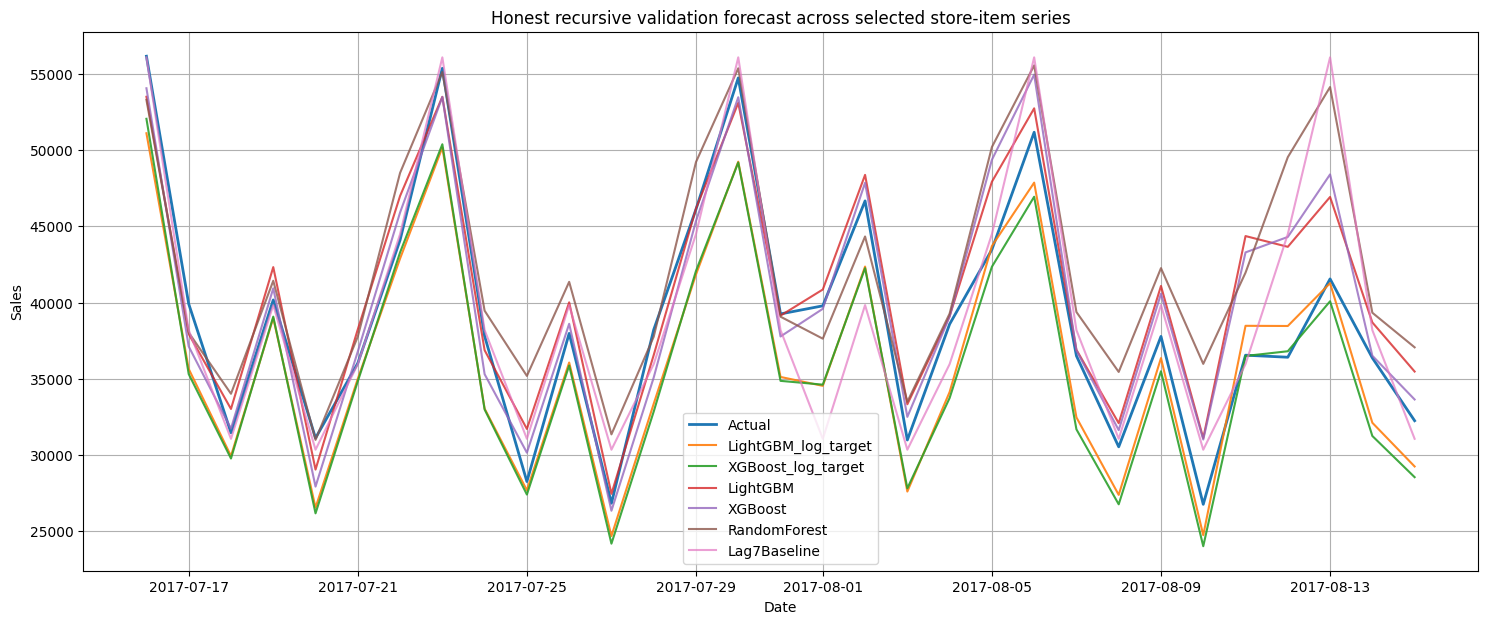

Feature importance for best model: LightGBM_log_target


,feature,importance
0,num__lag_1,6674
1,num__day,5558
2,num__days_since_first_observed,5520
3,num__lag_7,4063
4,num__week_of_year,3776
5,num__lag_14,3225
6,num__lag_28,3154
7,num__day_of_week,2804
8,num__ewm_mean_7,2714
9,num__rolling_std_7,2521


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Forecast example:
best model      = LightGBM_log_target
store_id        = 3
item_id         = 159156
date            = 2017-07-16
predicted sales = 25.5792236328125
actual sales    = 27.167


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/v

,date,store_nbr,item_nbr,actual,prediction,model
0,2017-07-16,3,159156,27.167,25.579224,LightGBM_log_target
1,2017-07-17,3,159156,20.554,12.422473,LightGBM_log_target
2,2017-07-18,3,159156,22.777,7.738528,LightGBM_log_target
3,2017-07-19,3,159156,35.151,9.819880,LightGBM_log_target
4,2017-07-20,3,159156,60.179,7.988348,LightGBM_log_target
5,2017-07-21,3,159156,50.363,19.891783,LightGBM_log_target
6,2017-07-22,3,159156,17.637,18.289663,LightGBM_log_target
7,2017-07-23,3,159156,70.080,19.221647,LightGBM_log_target


In [5]:
# ==========================================
# CELL 2: TRAIN + HONEST RECURSIVE EVALUATION + INFERENCE
# compatible with updated CELL 1
# ==========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor, early_stopping


# --------------------------------------------------
# 0. SAFETY CHECKS
# --------------------------------------------------
required_vars = [
    "train_df",
    "future_base_df",
    "valid_actuals_df",
    "history_seed_df",
    "feature_cols",
    "categorical_feature_cols",
    "numeric_feature_cols",
    "target_col",
    "log_target_col",
    "q_low",
    "q_high",
    "build_recursive_feature_rows_for_date",
]

for v in required_vars:
    if v not in globals():
        raise ValueError(f"Missing required variable from previous cell: {v}")

assert set(feature_cols).issubset(train_df.columns), "Some feature_cols are missing in train_df"
assert callable(build_recursive_feature_rows_for_date), "build_recursive_feature_rows_for_date must be defined"


# --------------------------------------------------
# 0.1 HELPERS FOR SAFE DTYPES
# --------------------------------------------------
ID_COLS = ["store_nbr", "item_nbr"]

def normalize_key_dtypes(df, id_cols=ID_COLS, date_col="date"):
    """
    Make merge keys consistent:
    - date -> datetime64[ns]
    - store_nbr/item_nbr -> int64
    """
    out = df.copy()

    if date_col in out.columns:
        out[date_col] = pd.to_datetime(out[date_col])

    for c in id_cols:
        if c in out.columns:
            out[c] = pd.to_numeric(out[c], errors="coerce")
            if out[c].isna().any():
                bad = out[out[c].isna()].head(5)
                raise ValueError(f"Column {c} contains non-numeric values after coercion. Sample:\n{bad}")
            out[c] = out[c].astype(np.int64)

    return out


def safe_first_row_value(df, col, filter_mask=None, name_for_error=None):
    tmp = df if filter_mask is None else df.loc[filter_mask]
    if tmp.empty:
        label = name_for_error or col
        raise ValueError(f"No rows available to extract {label}.")
    return tmp[col].iloc[0]


# --------------------------------------------------
# 0.2 LOAD WORKING COPIES
# --------------------------------------------------
train_ml = train_df.copy().reset_index(drop=True)
future_ml = future_base_df.copy().reset_index(drop=True)
valid_actuals_ml = valid_actuals_df.copy().reset_index(drop=True)
history_seed_ml = history_seed_df.copy().reset_index(drop=True)

# normalize only the merge / lookup frames
future_ml = normalize_key_dtypes(future_ml)
valid_actuals_ml = normalize_key_dtypes(valid_actuals_ml)
history_seed_ml = normalize_key_dtypes(history_seed_ml)

train_ml["date"] = pd.to_datetime(train_ml["date"])

if train_ml.empty:
    raise ValueError("train_df is empty.")
if future_ml.empty:
    raise ValueError("future_base_df is empty. No future horizon to evaluate.")
if valid_actuals_ml.empty:
    raise ValueError("valid_actuals_df is empty. No actuals for evaluation.")
if history_seed_ml.empty:
    raise ValueError("history_seed_df is empty. No seed history for recursive evaluation.")

print("Train rows:", train_ml.shape[0])
print("Future base rows:", future_ml.shape[0])
print("Valid actual rows:", valid_actuals_ml.shape[0])
print("Feature count:", len(feature_cols))
print("Categorical count:", len(categorical_feature_cols))
print("Numeric count:", len(numeric_feature_cols))


# --------------------------------------------------
# 1. PREPROCESSING
#    IMPORTANT: fit ONLY on train
# --------------------------------------------------
def make_ohe():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

def make_preprocessor():
    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
        ("ohe", make_ohe())
    ])

    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value=0.0))
    ])

    return ColumnTransformer(
        transformers=[
            ("cat", categorical_transformer, categorical_feature_cols),
            ("num", numeric_transformer, numeric_feature_cols),
        ],
        remainder="drop"
    )

preprocessor = make_preprocessor()

X_train_raw = train_ml[feature_cols].copy()
y_train = train_ml[target_col].to_numpy(dtype=np.float32)
y_train_log = train_ml[log_target_col].to_numpy(dtype=np.float32)

X_train = preprocessor.fit_transform(X_train_raw).astype(np.float32)

print("Encoded train shape:", X_train.shape)


# --------------------------------------------------
# 2. METRICS
# --------------------------------------------------
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def wape(y_true, y_pred):
    denom = float(np.sum(np.abs(y_true)))
    if denom == 0:
        return np.nan
    return float(np.sum(np.abs(y_true - y_pred)) / denom)

def smape(y_true, y_pred):
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    val = np.abs(y_true - y_pred) / np.where(denom == 0, 1.0, denom)
    return float(np.mean(val))

def evaluate_forecast(name, y_true, y_pred):
    y_true = np.asarray(y_true, dtype=np.float32)
    y_pred = np.clip(np.asarray(y_pred, dtype=np.float32), 0, None)

    return {
        "model": name,
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "RMSE": rmse(y_true, y_pred),
        "WAPE": wape(y_true, y_pred),
        "SMAPE": smape(y_true, y_pred),
        "R2": float(r2_score(y_true, y_pred))
    }


# --------------------------------------------------
# 3. TRAIN-ONLY INNER SPLIT FOR EARLY STOPPING
# --------------------------------------------------
unique_train_dates = np.array(sorted(train_ml["date"].unique()))
INNER_VALID_DAYS = 28

if len(unique_train_dates) <= INNER_VALID_DAYS + 30:
    raise ValueError("Not enough train dates for inner early-stopping split.")

inner_valid_start = pd.Timestamp(unique_train_dates[-INNER_VALID_DAYS])

inner_train_df = train_ml[train_ml["date"] < inner_valid_start].copy()
inner_valid_df = train_ml[train_ml["date"] >= inner_valid_start].copy()

print("Inner-train rows:", inner_train_df.shape[0])
print("Inner-valid rows:", inner_valid_df.shape[0])
print("Inner valid start:", inner_valid_start.date())

inner_preprocessor = make_preprocessor()

X_inner_train = inner_preprocessor.fit_transform(inner_train_df[feature_cols]).astype(np.float32)
X_inner_valid = inner_preprocessor.transform(inner_valid_df[feature_cols]).astype(np.float32)

y_inner_train = inner_train_df[target_col].to_numpy(dtype=np.float32)
y_inner_valid = inner_valid_df[target_col].to_numpy(dtype=np.float32)

y_inner_train_log = inner_train_df[log_target_col].to_numpy(dtype=np.float32)
y_inner_valid_log = inner_valid_df[log_target_col].to_numpy(dtype=np.float32)


# --------------------------------------------------
# 4. FIT MODELS
# --------------------------------------------------
train_results = []
test_results = []

# ---------- Random Forest ----------
rf_model = RandomForestRegressor(
    n_estimators=350,
    max_depth=18,
    min_samples_leaf=2,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

# ---------- XGBoost ----------
xgb_base_params = dict(
    learning_rate=0.03,
    max_depth=8,
    min_child_weight=3,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.0,
    reg_lambda=1.5,
    objective="reg:squarederror",
    eval_metric="rmse",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

xgb_probe_model = XGBRegressor(
    n_estimators=2000,
    early_stopping_rounds=100,
    **xgb_base_params
)
xgb_probe_model.fit(
    X_inner_train,
    y_inner_train,
    eval_set=[(X_inner_valid, y_inner_valid)],
    verbose=False
)

xgb_best_n = getattr(xgb_probe_model, "best_iteration", None)
xgb_best_n = 400 if xgb_best_n is None else int(xgb_best_n) + 1
print("XGBoost best n_estimators (raw):", xgb_best_n)

xgb_model = XGBRegressor(
    n_estimators=xgb_best_n,
    **xgb_base_params
)
xgb_model.fit(X_train, y_train, verbose=False)

xgb_log_probe_model = XGBRegressor(
    n_estimators=2000,
    early_stopping_rounds=100,
    **xgb_base_params
)
xgb_log_probe_model.fit(
    X_inner_train,
    y_inner_train_log,
    eval_set=[(X_inner_valid, y_inner_valid_log)],
    verbose=False
)

xgb_log_best_n = getattr(xgb_log_probe_model, "best_iteration", None)
xgb_log_best_n = 400 if xgb_log_best_n is None else int(xgb_log_best_n) + 1
print("XGBoost best n_estimators (log):", xgb_log_best_n)

xgb_log_model = XGBRegressor(
    n_estimators=xgb_log_best_n,
    **xgb_base_params
)
xgb_log_model.fit(X_train, y_train_log, verbose=False)

# ---------- LightGBM ----------
lgb_base_params = dict(
    learning_rate=0.03,
    num_leaves=63,
    max_depth=-1,
    min_child_samples=20,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.0,
    reg_lambda=1.5,
    objective="regression",
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

def fit_lgb_probe(X_tr, y_tr, X_val, y_val, params, n_estimators=2000, stopping_rounds=100):
    model = LGBMRegressor(
        n_estimators=n_estimators,
        **params
    )
    model.fit(
        X_tr,
        y_tr,
        eval_set=[(X_val, y_val)],
        eval_metric="rmse",
        callbacks=[early_stopping(stopping_rounds, verbose=False)]
    )
    return model

lgb_probe_model = fit_lgb_probe(
    X_inner_train,
    y_inner_train,
    X_inner_valid,
    y_inner_valid,
    lgb_base_params,
    n_estimators=2000,
    stopping_rounds=100
)

lgb_best_n = getattr(lgb_probe_model, "best_iteration_", None)
lgb_best_n = 400 if lgb_best_n is None or int(lgb_best_n) <= 0 else int(lgb_best_n)
print("LightGBM best n_estimators (raw):", lgb_best_n)

lgb_model = LGBMRegressor(
    n_estimators=lgb_best_n,
    **lgb_base_params
)
lgb_model.fit(X_train, y_train)

lgb_log_probe_model = fit_lgb_probe(
    X_inner_train,
    y_inner_train_log,
    X_inner_valid,
    y_inner_valid_log,
    lgb_base_params,
    n_estimators=2000,
    stopping_rounds=100
)

lgb_log_best_n = getattr(lgb_log_probe_model, "best_iteration_", None)
lgb_log_best_n = 400 if lgb_log_best_n is None or int(lgb_log_best_n) <= 0 else int(lgb_log_best_n)
print("LightGBM best n_estimators (log):", lgb_log_best_n)

lgb_log_model = LGBMRegressor(
    n_estimators=lgb_log_best_n,
    **lgb_base_params
)
lgb_log_model.fit(X_train, y_train_log)

# --------------------------------------------------
# 4.1 TRAIN METRICS (IN-SAMPLE, OPTIMISTIC)
# --------------------------------------------------
def evaluate_train_model(model_name):
    if model_name == "Lag7Baseline":
        y_pred = train_ml["lag_7"].to_numpy(dtype=np.float32)
    elif model_name == "RandomForest":
        y_pred = rf_model.predict(X_train)
    elif model_name == "XGBoost":
        y_pred = xgb_model.predict(X_train)
    elif model_name == "XGBoost_log_target":
        y_pred = np.expm1(xgb_log_model.predict(X_train))
    elif model_name == "LightGBM":
        y_pred = lgb_model.predict(X_train)
    elif model_name == "LightGBM_log_target":
        y_pred = np.expm1(lgb_log_model.predict(X_train))
    else:
        raise ValueError(f"Unknown model_name: {model_name}")

    return evaluate_forecast(
        name=model_name,
        y_true=y_train,
        y_pred=y_pred,
    )

train_results.append(evaluate_train_model("Lag7Baseline"))
train_results.append(evaluate_train_model("RandomForest"))
train_results.append(evaluate_train_model("XGBoost"))
train_results.append(evaluate_train_model("XGBoost_log_target"))
train_results.append(evaluate_train_model("LightGBM"))
train_results.append(evaluate_train_model("LightGBM_log_target"))

train_metrics_df = pd.DataFrame(train_results).sort_values(["RMSE", "MAE"]).reset_index(drop=True)

print("TRAIN metrics (in-sample, optimistic):")
display(train_metrics_df)

# --------------------------------------------------
# 5. HONEST RECURSIVE PREDICTION HELPERS
# --------------------------------------------------
def _predict_rows_for_model(model_name, x_today_df):
    if model_name == "Lag7Baseline":
        yhat = x_today_df["lag_7"].to_numpy(dtype=np.float32)
    else:
        X_today = preprocessor.transform(x_today_df[feature_cols]).astype(np.float32)

        if model_name == "RandomForest":
            yhat = rf_model.predict(X_today)
        elif model_name == "XGBoost":
            yhat = xgb_model.predict(X_today)
        elif model_name == "XGBoost_log_target":
            yhat = np.expm1(xgb_log_model.predict(X_today))
        elif model_name == "LightGBM":
            yhat = lgb_model.predict(X_today)
        elif model_name == "LightGBM_log_target":
            yhat = np.expm1(lgb_log_model.predict(X_today))
        else:
            raise ValueError(f"Unknown model_name: {model_name}")

    yhat = np.clip(np.asarray(yhat, dtype=np.float32), 0, None)
    return yhat


def recursive_predict_frame(model_name, future_frame, history_seed_frame):
    """
    Honest recursive prediction over future_frame.
    Output keys are normalized to numeric dtypes for safe merge.
    """
    future_frame = normalize_key_dtypes(future_frame)
    history_df = normalize_key_dtypes(history_seed_frame)

    future_frame = future_frame.sort_values(["date", "store_nbr", "item_nbr"]).reset_index(drop=True)
    history_df = history_df.sort_values(["store_nbr", "item_nbr", "date"]).reset_index(drop=True)

    pred_batches = []

    for pred_date in sorted(future_frame["date"].unique()):
        x_today = build_recursive_feature_rows_for_date(
            pred_date=pd.Timestamp(pred_date),
            future_base_df=future_frame,
            history_seed_df=history_df,
            q_low=q_low,
            q_high=q_high,
            categorical_cols=categorical_feature_cols,
            numeric_cols=numeric_feature_cols,
        )

        if x_today.empty:
            continue

        yhat = _predict_rows_for_model(model_name, x_today)

        batch_pred = pd.DataFrame({
            "date": pd.to_datetime(x_today["date"]),
            "store_nbr": pd.to_numeric(x_today["store_nbr"], errors="coerce").astype(np.int64),
            "item_nbr": pd.to_numeric(x_today["item_nbr"], errors="coerce").astype(np.int64),
            "prediction": yhat,
            "model": model_name,
        })

        pred_batches.append(batch_pred)

        hist_add = pd.DataFrame({
            "date": pd.to_datetime(x_today["date"]),
            "store_nbr": pd.to_numeric(x_today["store_nbr"], errors="coerce").astype(np.int64),
            "item_nbr": pd.to_numeric(x_today["item_nbr"], errors="coerce").astype(np.int64),
            "onpromotion": pd.to_numeric(x_today["onpromotion"], errors="coerce").fillna(0).astype(np.int64),
            "sales": yhat,
        })

        hist_add["log_sales"] = np.log1p(hist_add["sales"])
        hist_add["sales_capped"] = np.clip(hist_add["sales"], q_low, q_high)

        history_df = pd.concat(
            [
                history_df[["date", "store_nbr", "item_nbr", "onpromotion", "sales", "log_sales", "sales_capped"]],
                hist_add[["date", "store_nbr", "item_nbr", "onpromotion", "sales", "log_sales", "sales_capped"]],
            ],
            ignore_index=True
        ).sort_values(["store_nbr", "item_nbr", "date"]).reset_index(drop=True)

        history_df = normalize_key_dtypes(history_df)

    if pred_batches:
        out = pd.concat(pred_batches, ignore_index=True)
        out = normalize_key_dtypes(out)
        return out

    return pd.DataFrame(columns=["date", "store_nbr", "item_nbr", "prediction", "model"])


def evaluate_recursive_model(model_name):
    pred_df = recursive_predict_frame(
        model_name=model_name,
        future_frame=future_ml,
        history_seed_frame=history_seed_ml,
    )

    if pred_df.empty:
        raise ValueError(f"No predictions produced for {model_name}")

    pred_df = normalize_key_dtypes(pred_df)
    actual_df = normalize_key_dtypes(valid_actuals_ml)

    eval_df = pred_df.merge(
        actual_df,
        on=["date", "store_nbr", "item_nbr"],
        how="inner",
        validate="1:1"
    )

    if eval_df.empty:
        raise ValueError(
            f"No evaluation rows for {model_name}. "
            f"Check whether prediction keys match valid_actuals keys."
        )

    metrics = evaluate_forecast(
        name=model_name,
        y_true=eval_df["sales_actual"].to_numpy(dtype=np.float32),
        y_pred=eval_df["prediction"].to_numpy(dtype=np.float32),
    )

    return pred_df, eval_df, metrics


# --------------------------------------------------
# 6. HONEST RECURSIVE EVALUATION
# --------------------------------------------------
lag7_pred_df, lag7_eval_df, lag7_metrics = evaluate_recursive_model("Lag7Baseline")
test_results.append(lag7_metrics)

rf_pred_df, rf_eval_df, rf_metrics = evaluate_recursive_model("RandomForest")
test_results.append(rf_metrics)

xgb_pred_df, xgb_eval_df, xgb_metrics = evaluate_recursive_model("XGBoost")
test_results.append(xgb_metrics)

xgb_log_pred_df, xgb_log_eval_df, xgb_log_metrics = evaluate_recursive_model("XGBoost_log_target")
test_results.append(xgb_log_metrics)

lgb_pred_df, lgb_eval_df, lgb_metrics = evaluate_recursive_model("LightGBM")
test_results.append(lgb_metrics)

lgb_log_pred_df, lgb_log_eval_df, lgb_log_metrics = evaluate_recursive_model("LightGBM_log_target")
test_results.append(lgb_log_metrics)

test_metrics_df = pd.DataFrame(test_results).sort_values(["RMSE", "MAE"]).reset_index(drop=True)

print("TEST metrics (honest recursive future horizon):")
display(test_metrics_df)

best_model_name = str(test_metrics_df.iloc[0]["model"])
print("Best model by RMSE/MAE on TEST:", best_model_name)

# --------------------------------------------------
# 6.1 TRAIN VS TEST COMPARISON
# --------------------------------------------------
combined_metrics_df = pd.concat(
    [
        train_metrics_df.assign(split="train"),
        test_metrics_df.assign(split="test"),
    ],
    ignore_index=True
)

combined_metrics_df = combined_metrics_df[
    ["split", "model", "MAE", "RMSE", "WAPE", "SMAPE", "R2"]
].sort_values(["model", "split"]).reset_index(drop=True)

print("TRAIN vs TEST metrics:")
display(combined_metrics_df)

gap_df = (
    train_metrics_df.set_index("model").add_prefix("train_")
    .join(test_metrics_df.set_index("model").add_prefix("test_"), how="inner")
    .reset_index()
)

gap_df["RMSE_gap"] = gap_df["test_RMSE"] - gap_df["train_RMSE"]
gap_df["MAE_gap"] = gap_df["test_MAE"] - gap_df["train_MAE"]
gap_df["WAPE_gap"] = gap_df["test_WAPE"] - gap_df["train_WAPE"]
gap_df["R2_gap"] = gap_df["test_R2"] - gap_df["train_R2"]

print("Generalization gap (test - train):")
display(
    gap_df[
        [
            "model",
            "train_RMSE", "test_RMSE", "RMSE_gap",
            "train_MAE", "test_MAE", "MAE_gap",
            "train_WAPE", "test_WAPE", "WAPE_gap",
            "train_R2", "test_R2", "R2_gap",
        ]
    ].sort_values("test_RMSE").reset_index(drop=True)
)

# --------------------------------------------------
# 7. CONSISTENCY CHECKS
# --------------------------------------------------
expected_rows = valid_actuals_ml.shape[0]

print("Expected valid rows:", expected_rows)
print("Lag7 predicted rows:", lag7_eval_df.shape[0])
print("RF predicted rows:", rf_eval_df.shape[0])
print("XGB predicted rows:", xgb_eval_df.shape[0])
print("XGB log predicted rows:", xgb_log_eval_df.shape[0])
print("LGB predicted rows:", lgb_eval_df.shape[0])
print("LGB log predicted rows:", lgb_log_eval_df.shape[0])


# --------------------------------------------------
# 8. AGGREGATED VALIDATION PLOT
# --------------------------------------------------
plot_df = valid_actuals_ml[["date", "store_nbr", "item_nbr", "sales_actual"]].copy()

plot_df = plot_df.merge(
    lag7_pred_df[["date", "store_nbr", "item_nbr", "prediction"]].rename(columns={"prediction": "Lag7Baseline"}),
    on=["date", "store_nbr", "item_nbr"],
    how="left"
)
plot_df = plot_df.merge(
    rf_pred_df[["date", "store_nbr", "item_nbr", "prediction"]].rename(columns={"prediction": "RandomForest"}),
    on=["date", "store_nbr", "item_nbr"],
    how="left"
)
plot_df = plot_df.merge(
    xgb_pred_df[["date", "store_nbr", "item_nbr", "prediction"]].rename(columns={"prediction": "XGBoost"}),
    on=["date", "store_nbr", "item_nbr"],
    how="left"
)
plot_df = plot_df.merge(
    xgb_log_pred_df[["date", "store_nbr", "item_nbr", "prediction"]].rename(columns={"prediction": "XGBoost_log_target"}),
    on=["date", "store_nbr", "item_nbr"],
    how="left"
)
plot_df = plot_df.merge(
    lgb_pred_df[["date", "store_nbr", "item_nbr", "prediction"]].rename(columns={"prediction": "LightGBM"}),
    on=["date", "store_nbr", "item_nbr"],
    how="left"
)
plot_df = plot_df.merge(
    lgb_log_pred_df[["date", "store_nbr", "item_nbr", "prediction"]].rename(columns={"prediction": "LightGBM_log_target"}),
    on=["date", "store_nbr", "item_nbr"],
    how="left"
)

daily_plot = (
    plot_df
    .groupby("date", as_index=False)[
        ["sales_actual", "Lag7Baseline", "RandomForest", "XGBoost", "XGBoost_log_target", "LightGBM", "LightGBM_log_target"]
    ]
    .sum()
    .rename(columns={"sales_actual": "Actual"})
)

plt.figure(figsize=(18, 7))
plt.plot(daily_plot["date"], daily_plot["Actual"], label="Actual", linewidth=2)
plt.plot(daily_plot["date"], daily_plot["LightGBM_log_target"], label="LightGBM_log_target", alpha=0.9)
plt.plot(daily_plot["date"], daily_plot["XGBoost_log_target"], label="XGBoost_log_target", alpha=0.9)
plt.plot(daily_plot["date"], daily_plot["LightGBM"], label="LightGBM", alpha=0.8)
plt.plot(daily_plot["date"], daily_plot["XGBoost"], label="XGBoost", alpha=0.8)
plt.plot(daily_plot["date"], daily_plot["RandomForest"], label="RandomForest", alpha=0.8)
plt.plot(daily_plot["date"], daily_plot["Lag7Baseline"], label="Lag7Baseline", alpha=0.7)
plt.title("Honest recursive validation forecast across selected store-item series")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.show()


# --------------------------------------------------
# 9. FEATURE IMPORTANCE
# --------------------------------------------------
try:
    transformed_feature_names = preprocessor.get_feature_names_out()
except Exception:
    transformed_feature_names = [f"f_{i}" for i in range(X_train.shape[1])]

if best_model_name == "XGBoost":
    best_importances = xgb_model.feature_importances_
elif best_model_name == "XGBoost_log_target":
    best_importances = xgb_log_model.feature_importances_
elif best_model_name == "LightGBM":
    best_importances = lgb_model.feature_importances_
elif best_model_name == "LightGBM_log_target":
    best_importances = lgb_log_model.feature_importances_
elif best_model_name == "RandomForest":
    best_importances = rf_model.feature_importances_
else:
    best_importances = None

if best_importances is not None:
    feat_imp = pd.DataFrame({
        "feature": transformed_feature_names,
        "importance": best_importances
    }).sort_values("importance", ascending=False).reset_index(drop=True)

    print("Feature importance for best model:", best_model_name)
    display(feat_imp.head(25))
else:
    print(f"Feature importance not available for model: {best_model_name}")


# --------------------------------------------------
# 10. INFERENCE HELPERS
# --------------------------------------------------
def forecast_series_on_known_horizon(store_id, item_id, start_date=None, end_date=None, model_name=None):
    if model_name is None:
        model_name = best_model_name

    future_subset = future_ml[
        (future_ml["store_nbr"] == int(store_id)) &
        (future_ml["item_nbr"] == int(item_id))
    ].copy()

    if future_subset.empty:
        raise ValueError(f"No future_base rows found for store_id={store_id}, item_id={item_id}")

    if start_date is not None:
        start_dt = pd.Timestamp(start_date).normalize()
        future_subset = future_subset[future_subset["date"] >= start_dt].copy()

    if end_date is not None:
        end_dt = pd.Timestamp(end_date).normalize()
        future_subset = future_subset[future_subset["date"] <= end_dt].copy()

    if future_subset.empty:
        raise ValueError("No rows remain after date filtering.")

    pred_df = recursive_predict_frame(
        model_name=model_name,
        future_frame=future_subset,
        history_seed_frame=history_seed_ml,
    )

    return pred_df.sort_values(["date"]).reset_index(drop=True)


def forecast_one_known_date(store_id, item_id, forecast_date, model_name=None):
    if model_name is None:
        model_name = best_model_name

    out = forecast_series_on_known_horizon(
        store_id=store_id,
        item_id=item_id,
        start_date=forecast_date,
        end_date=forecast_date,
        model_name=model_name
    )

    if out.empty:
        raise ValueError("No prediction returned.")

    return float(out["prediction"].iloc[0])


# --------------------------------------------------
# 11. EXAMPLE INFERENCE
# --------------------------------------------------
if valid_actuals_ml.empty:
    print("Skipping inference example because valid_actuals_ml is empty.")
else:
    example_store = int(safe_first_row_value(valid_actuals_ml, "store_nbr", name_for_error="example_store"))
    same_store_mask = valid_actuals_ml["store_nbr"] == example_store
    example_item = int(safe_first_row_value(valid_actuals_ml, "item_nbr", filter_mask=same_store_mask, name_for_error="example_item"))
    example_date = str(valid_actuals_ml["date"].min().date())

    pred_example = forecast_one_known_date(
        store_id=example_store,
        item_id=example_item,
        forecast_date=example_date,
        model_name=best_model_name
    )

    actual_mask = (
        (valid_actuals_ml["store_nbr"] == example_store) &
        (valid_actuals_ml["item_nbr"] == example_item) &
        (valid_actuals_ml["date"] == pd.Timestamp(example_date))
    )

    actual_example = None
    if actual_mask.any():
        actual_example = float(valid_actuals_ml.loc[actual_mask, "sales_actual"].iloc[0])

    print("Forecast example:")
    print("best model      =", best_model_name)
    print("store_id        =", example_store)
    print("item_id         =", example_item)
    print("date            =", example_date)
    print("predicted sales =", pred_example)
    print("actual sales    =", actual_example)

    # --------------------------------------------------
    # 12. OPTIONAL: MULTI-DAY FORECAST EXAMPLE + ACTUAL
    # --------------------------------------------------
    horizon_end = str((pd.Timestamp(example_date) + pd.Timedelta(days=7)).date())

    example_horizon = forecast_series_on_known_horizon(
        store_id=example_store,
        item_id=example_item,
        start_date=example_date,
        end_date=horizon_end,
        model_name=best_model_name
    )

    example_horizon = example_horizon.merge(
        valid_actuals_ml[["date", "store_nbr", "item_nbr", "sales_actual"]],
        on=["date", "store_nbr", "item_nbr"],
        how="left"
    )

    example_horizon = example_horizon.rename(columns={"sales_actual": "actual"})
    example_horizon = example_horizon[
        ["date", "store_nbr", "item_nbr", "actual", "prediction", "model"]
    ]

    display(example_horizon)

NameError: name 'lag7_train_eval_df' is not defined

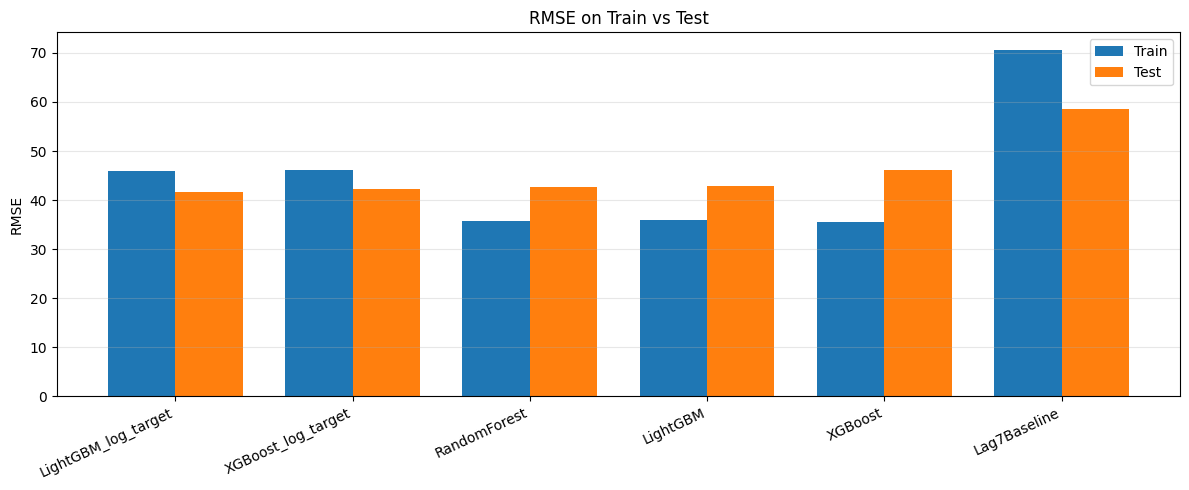

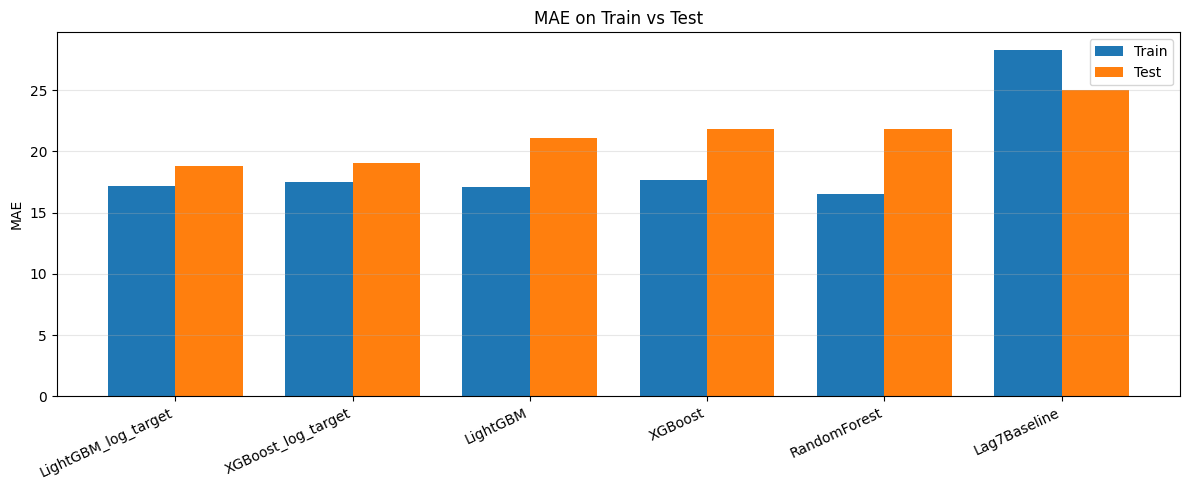

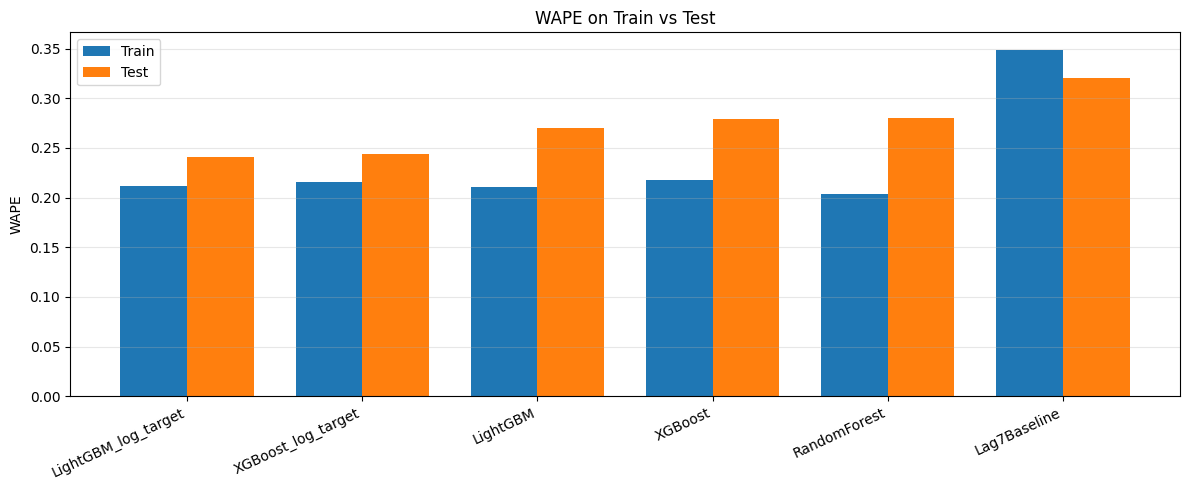

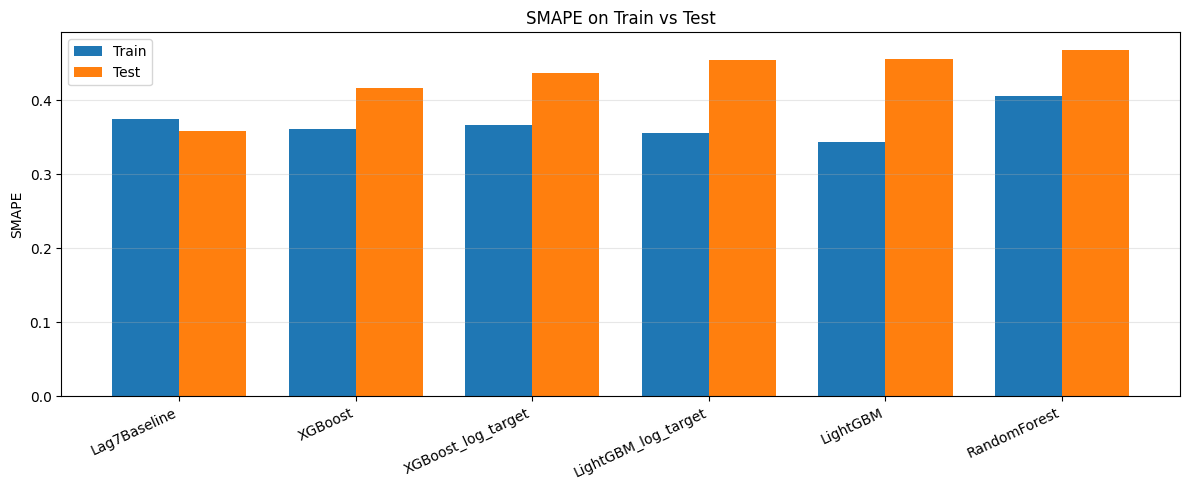

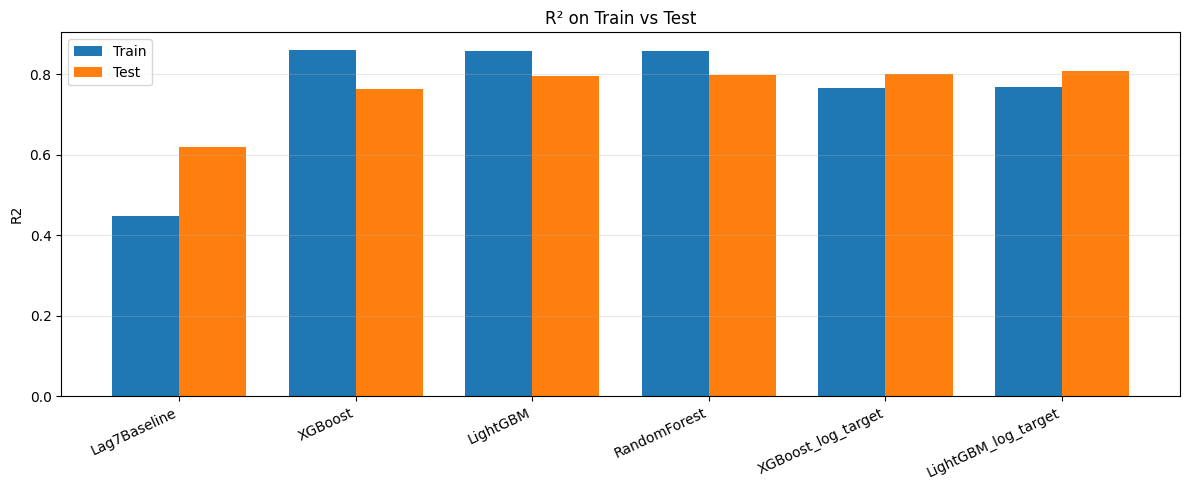

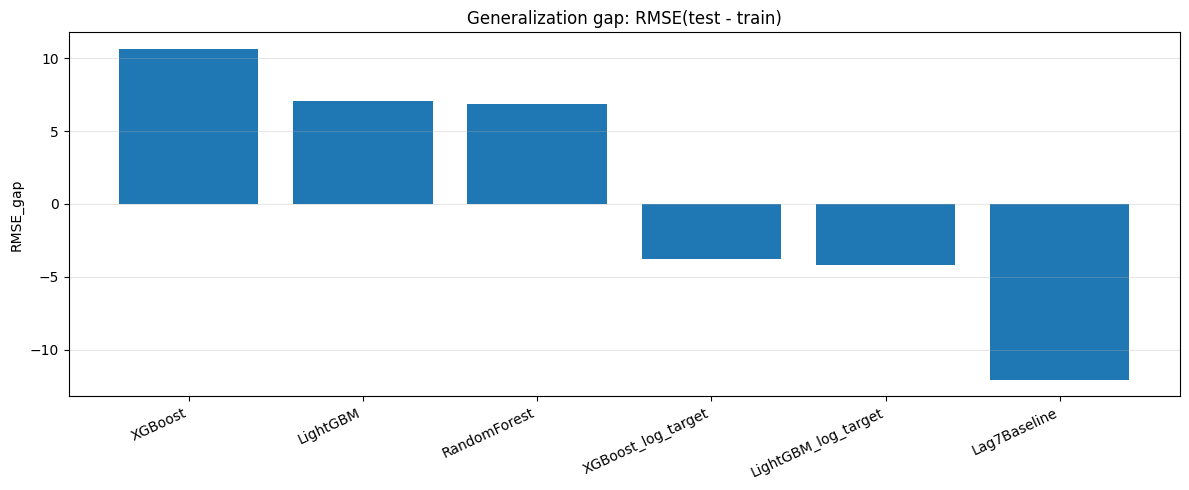

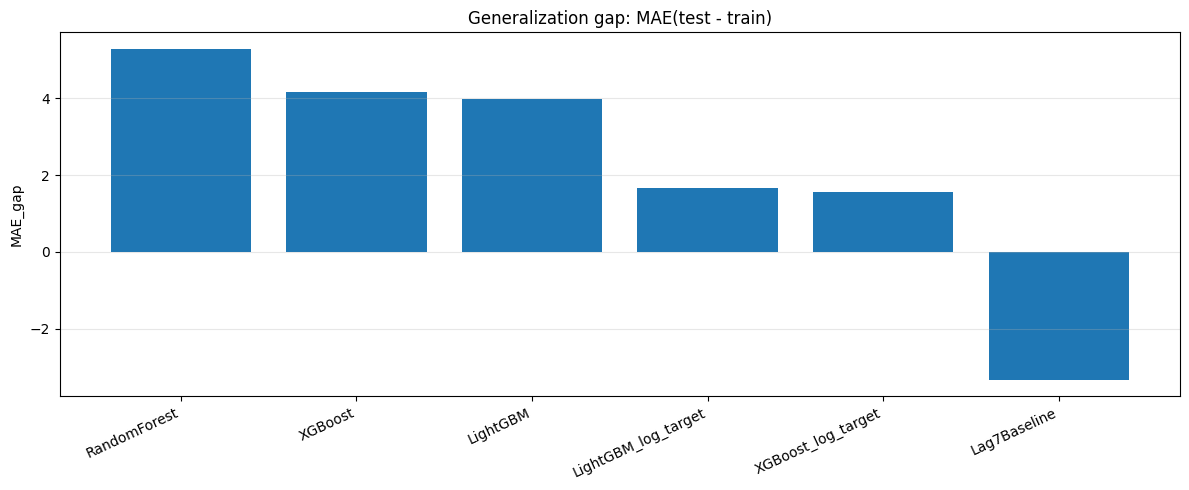

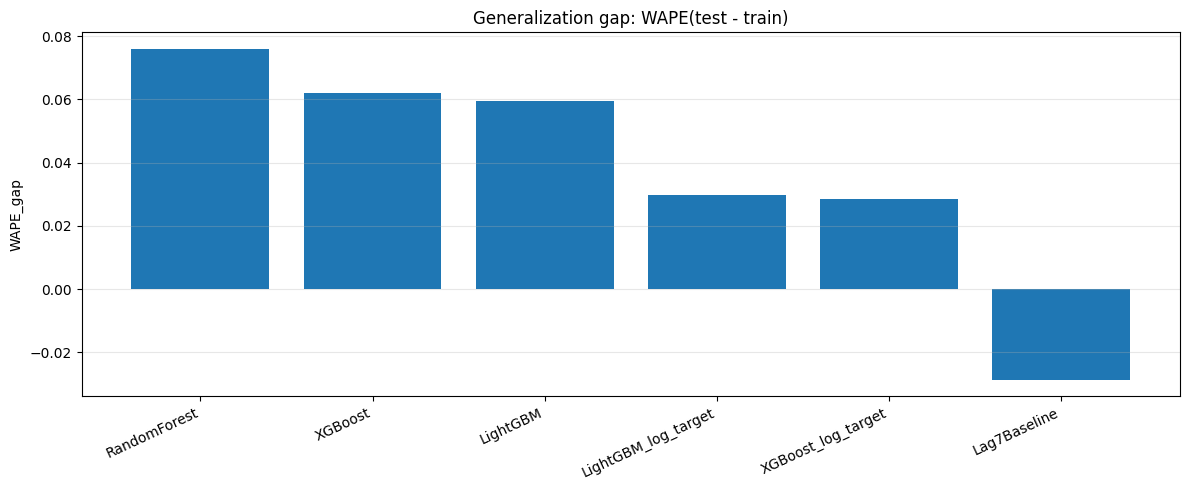

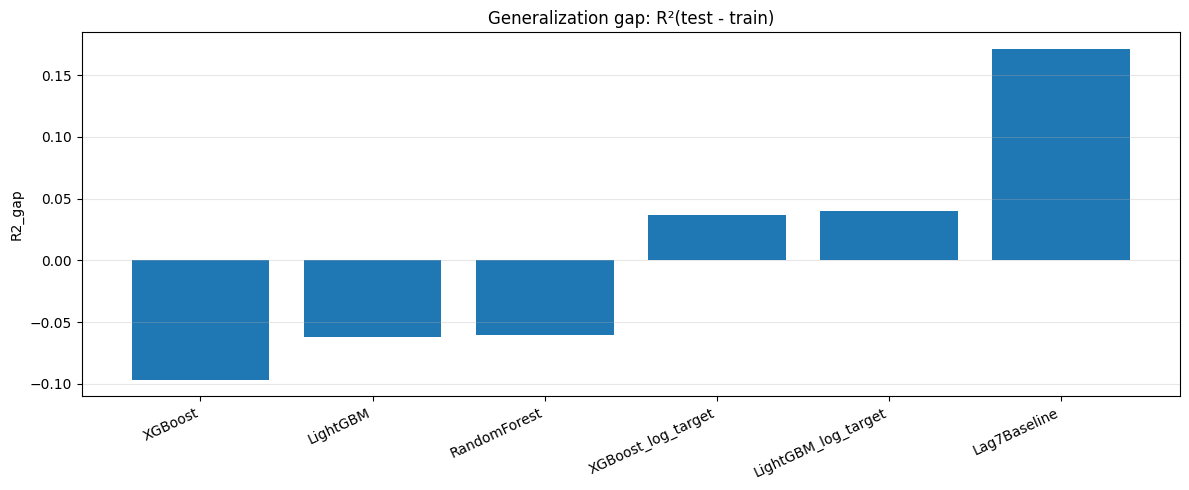

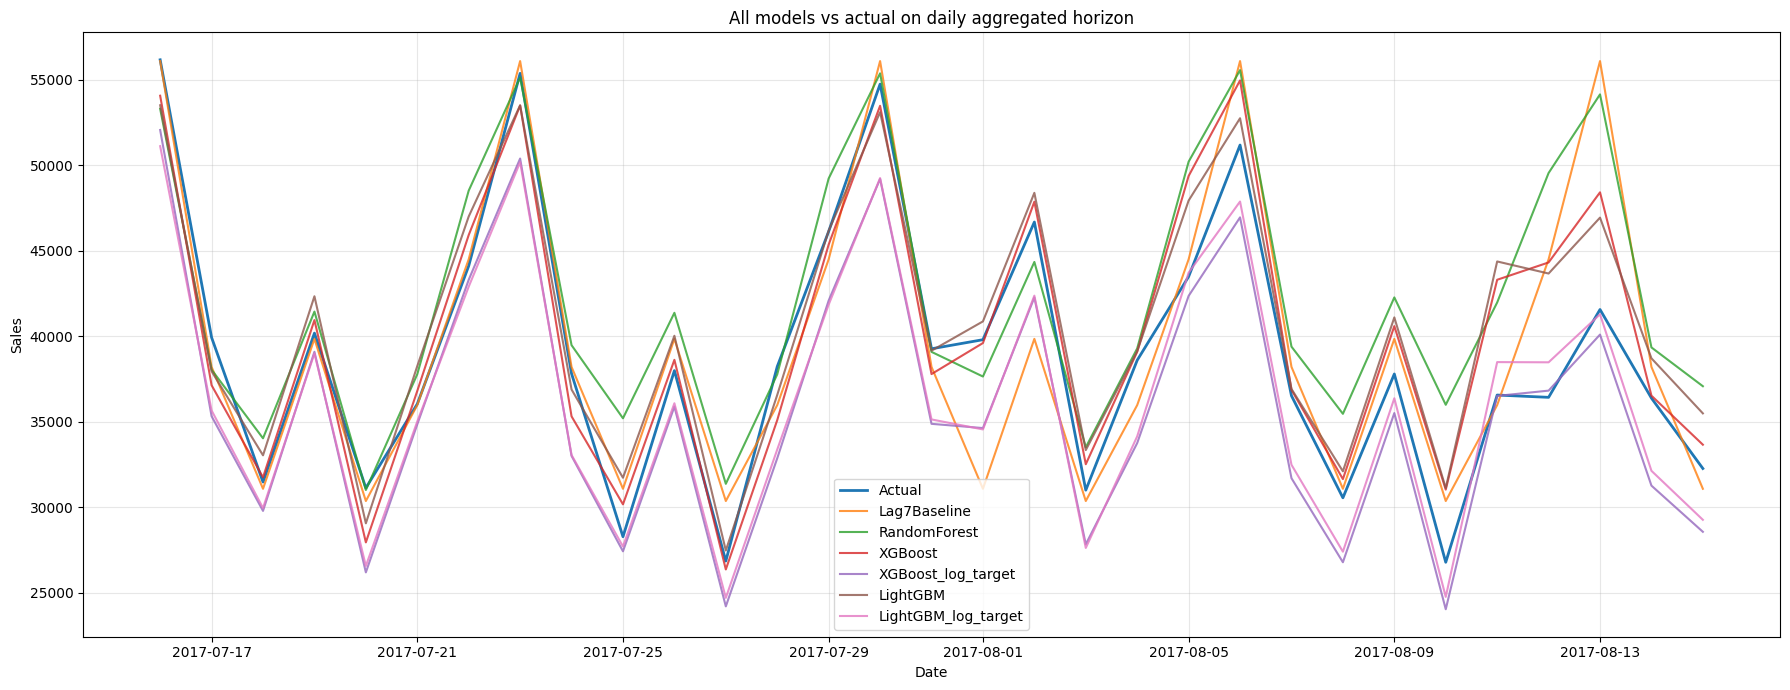

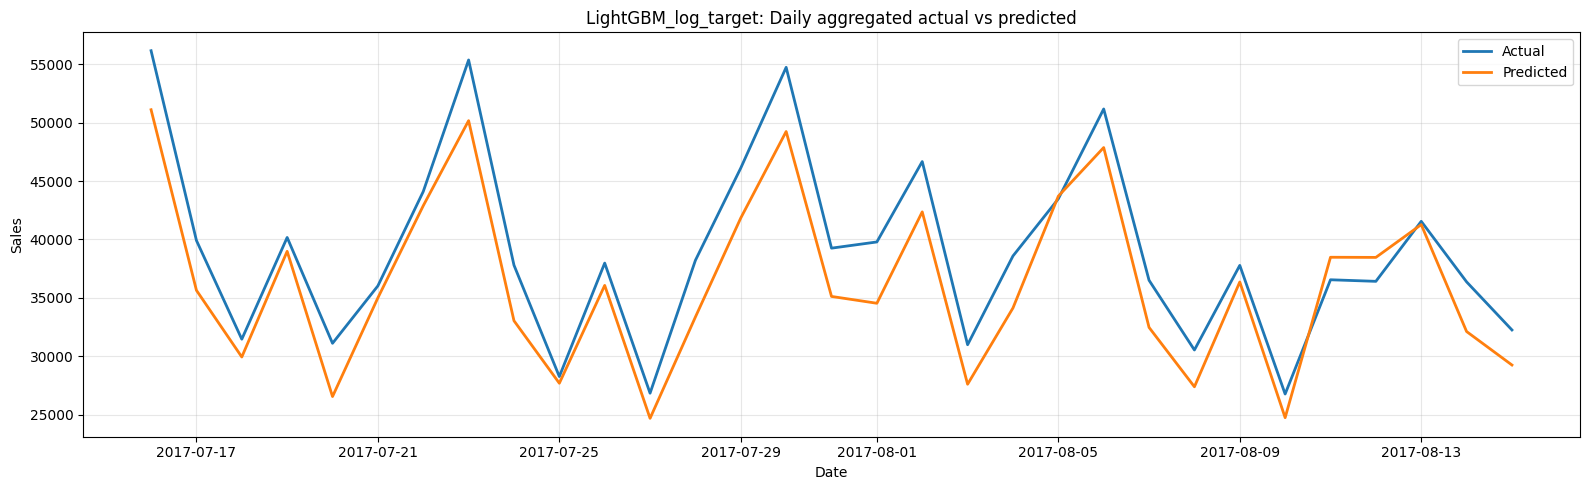

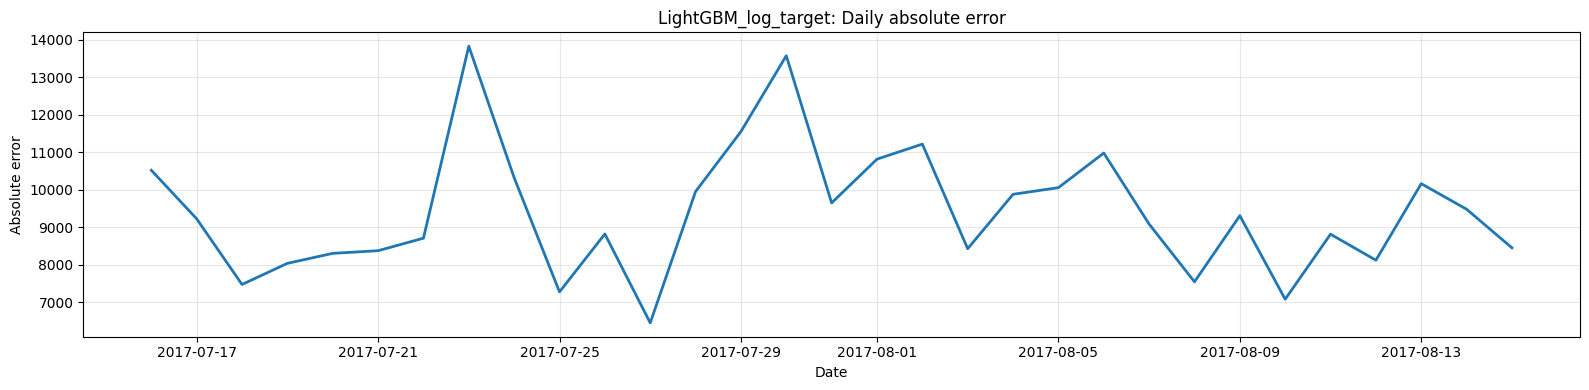

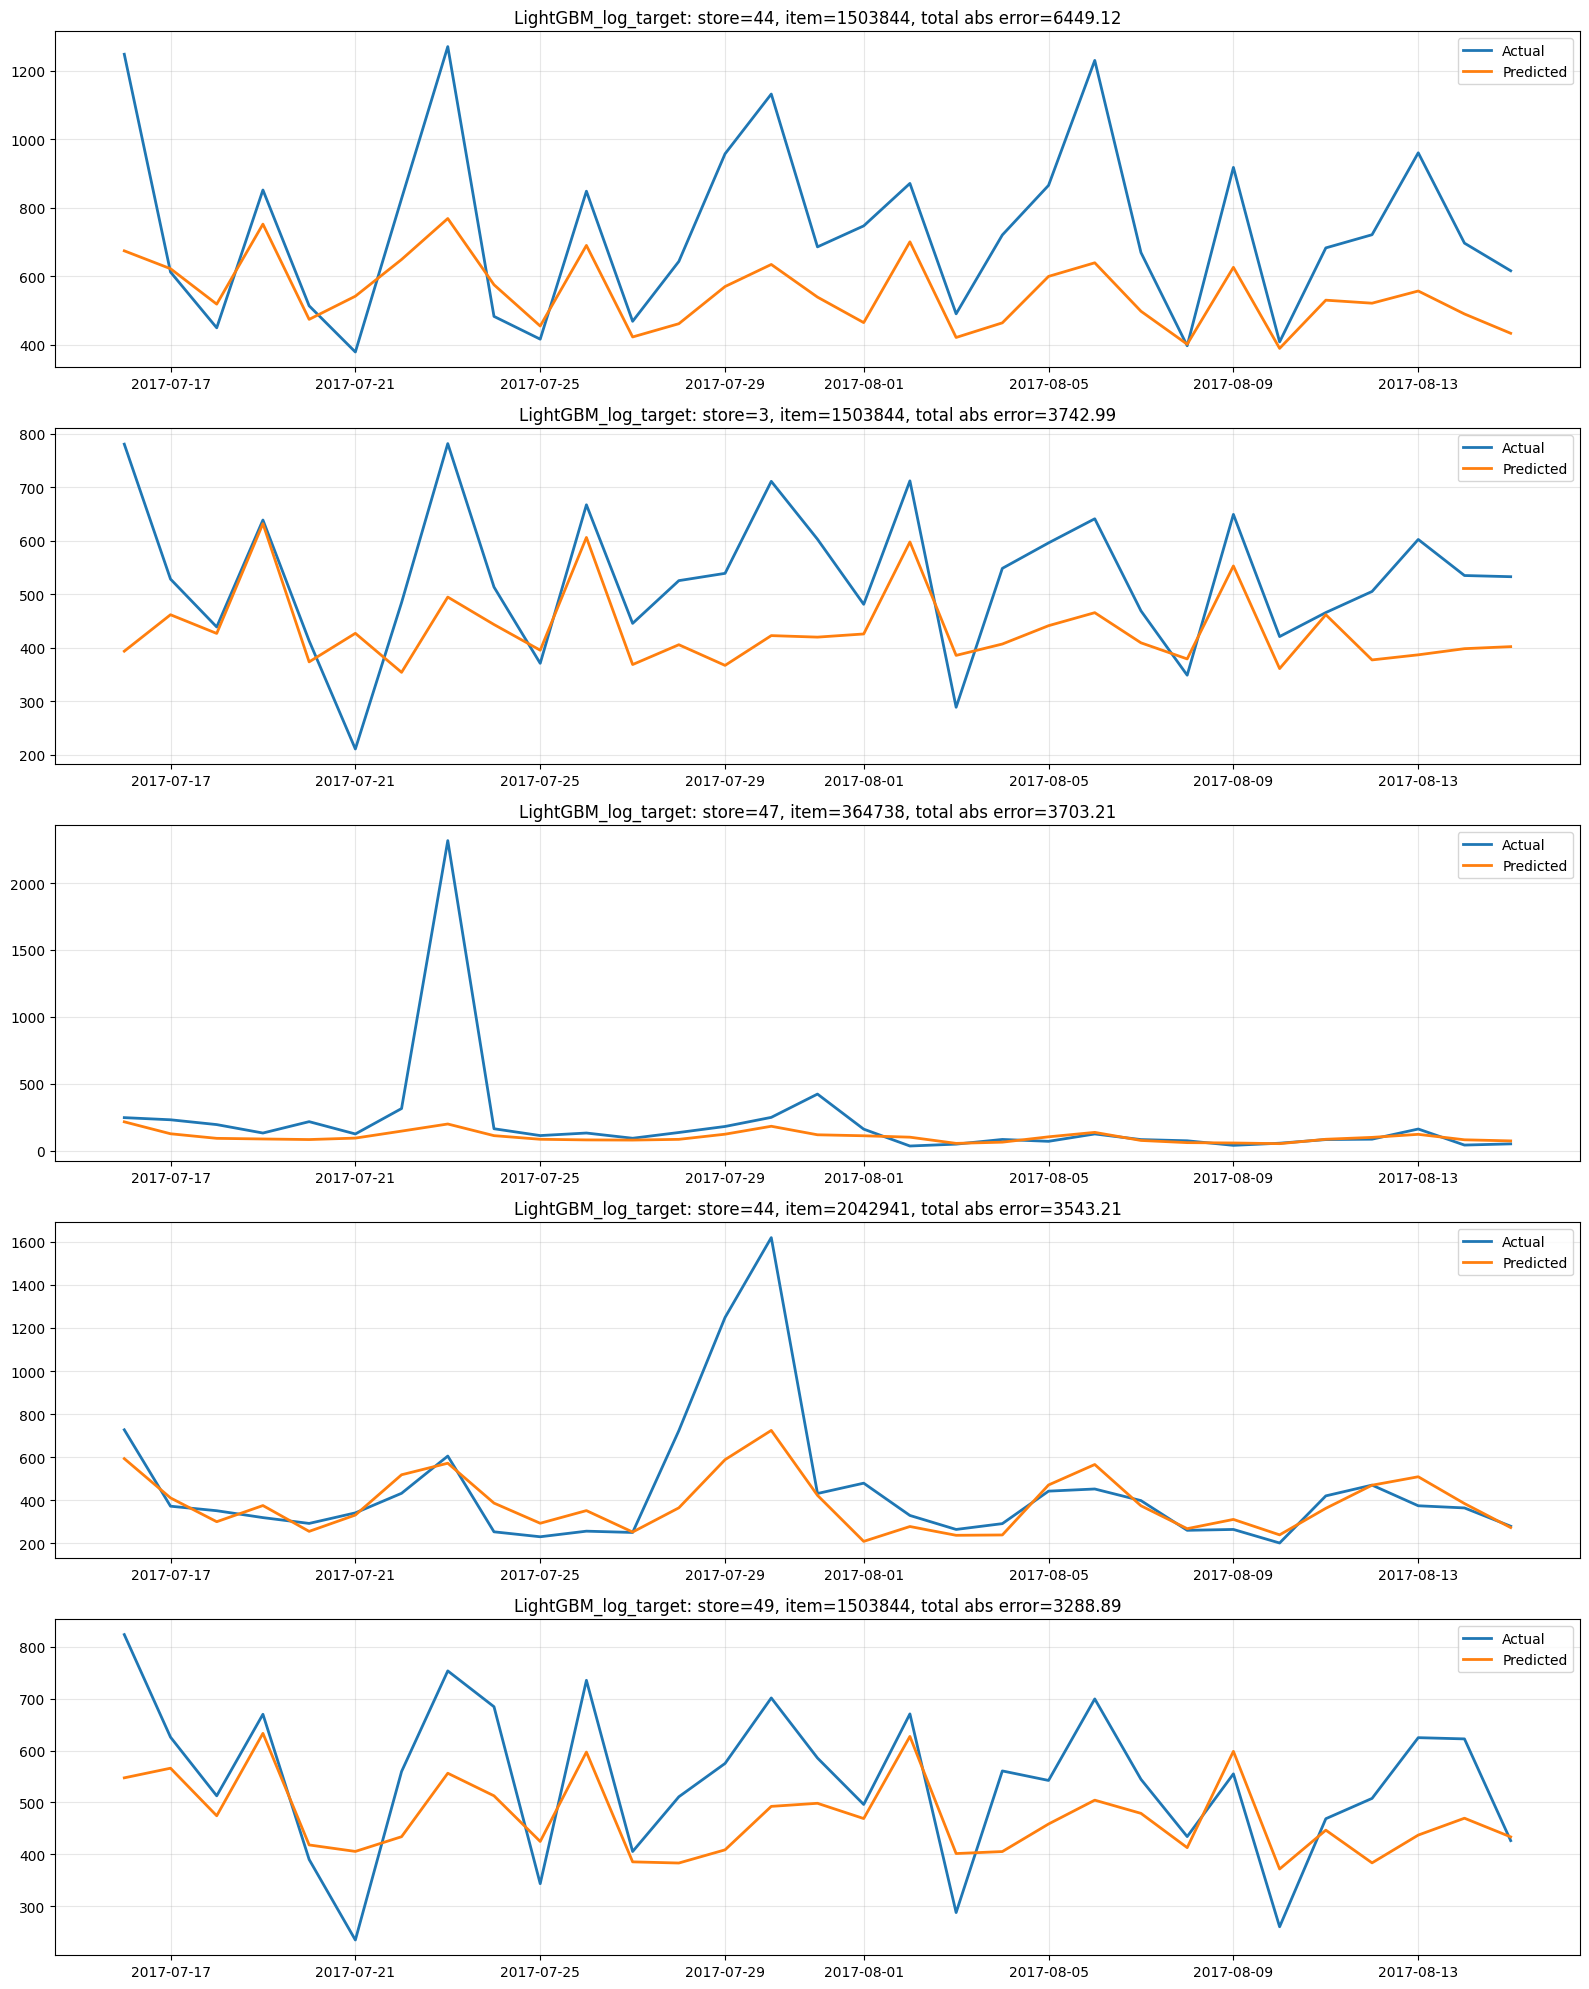

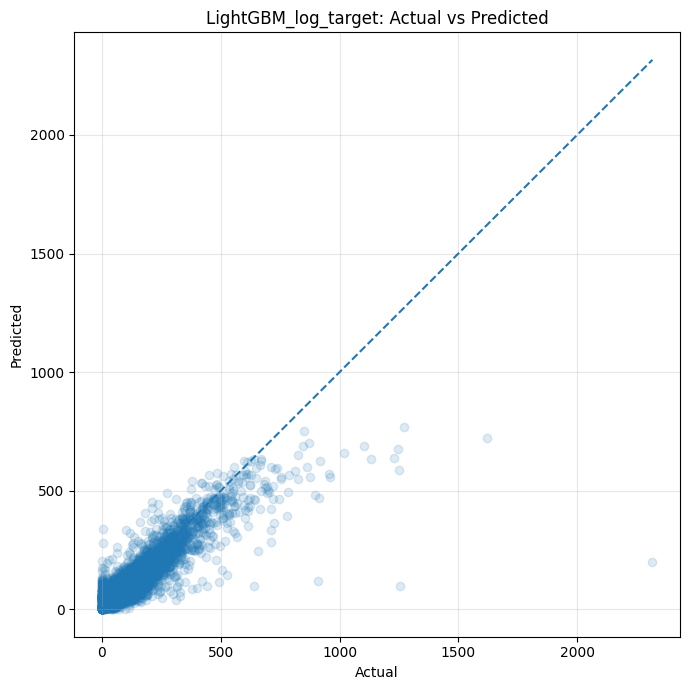

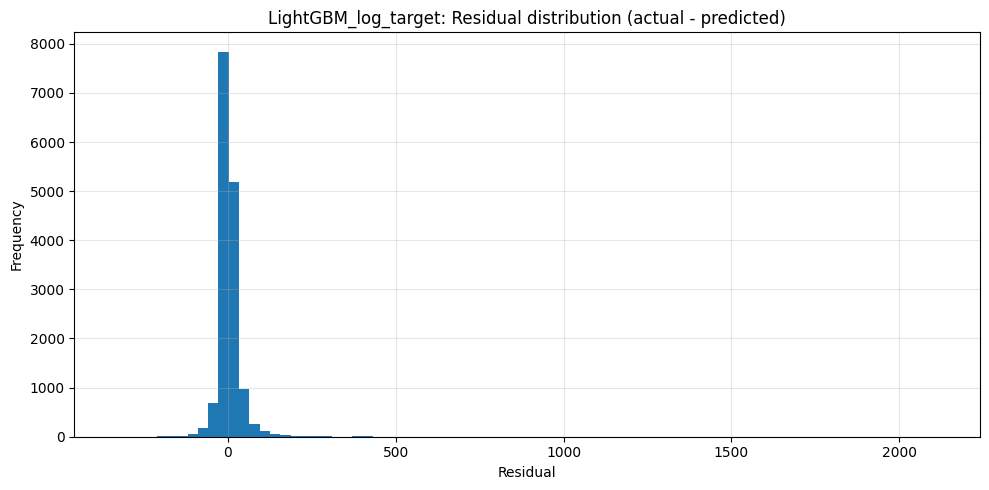

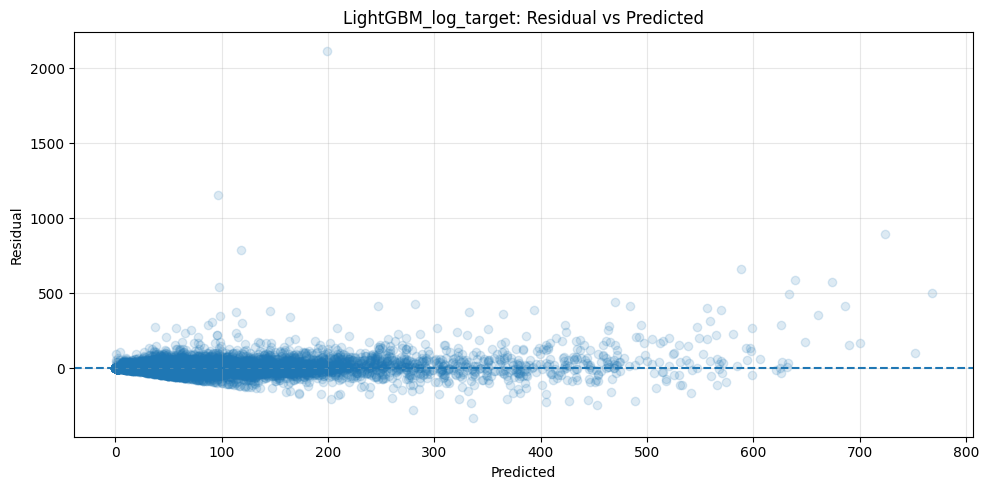

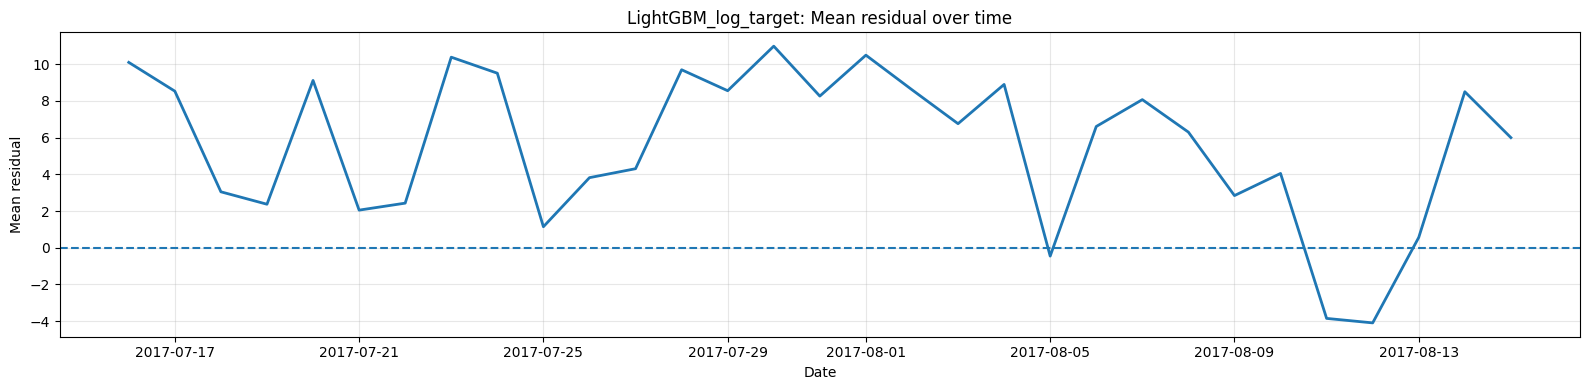

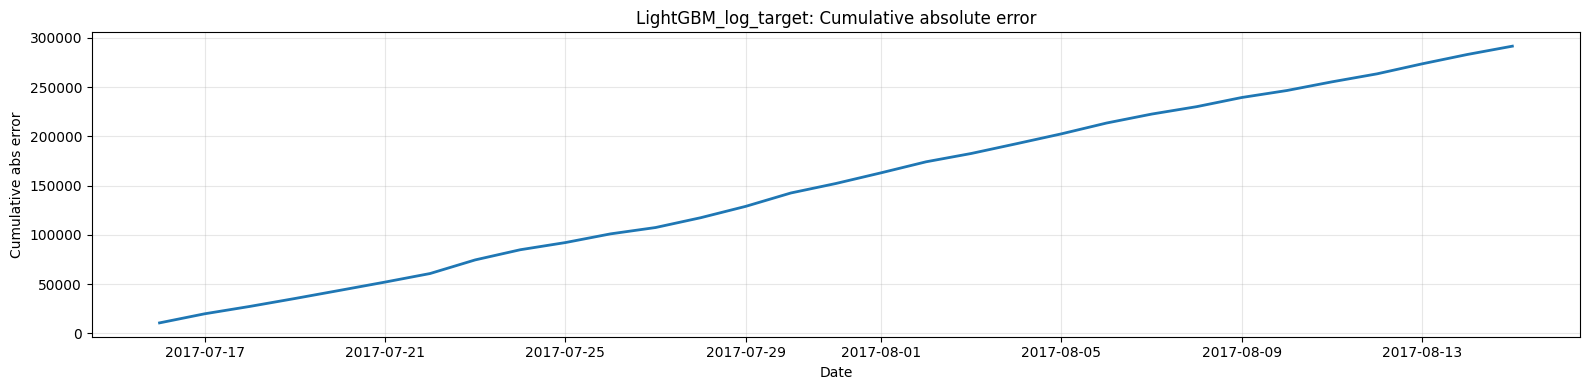

MODEL: Lag7Baseline


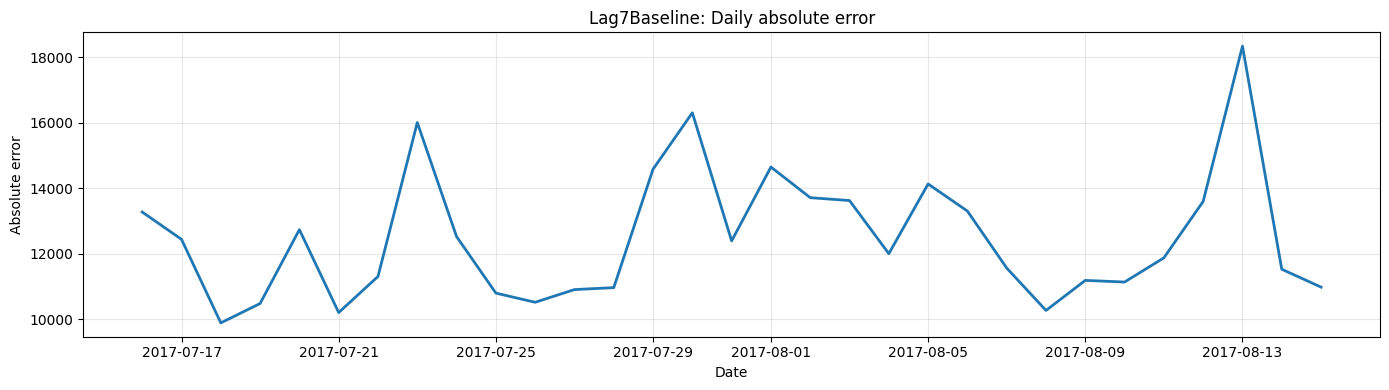

MODEL: RandomForest


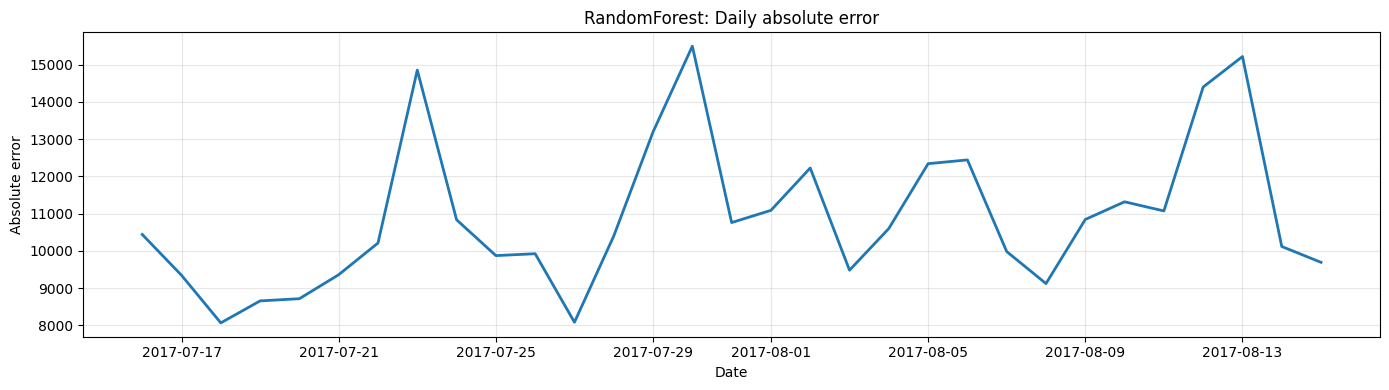

MODEL: XGBoost


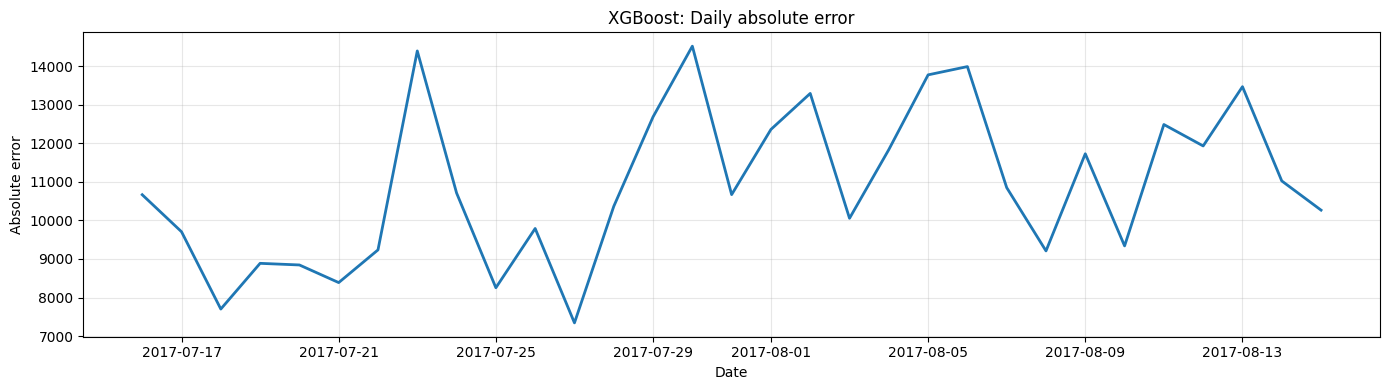

MODEL: XGBoost_log_target


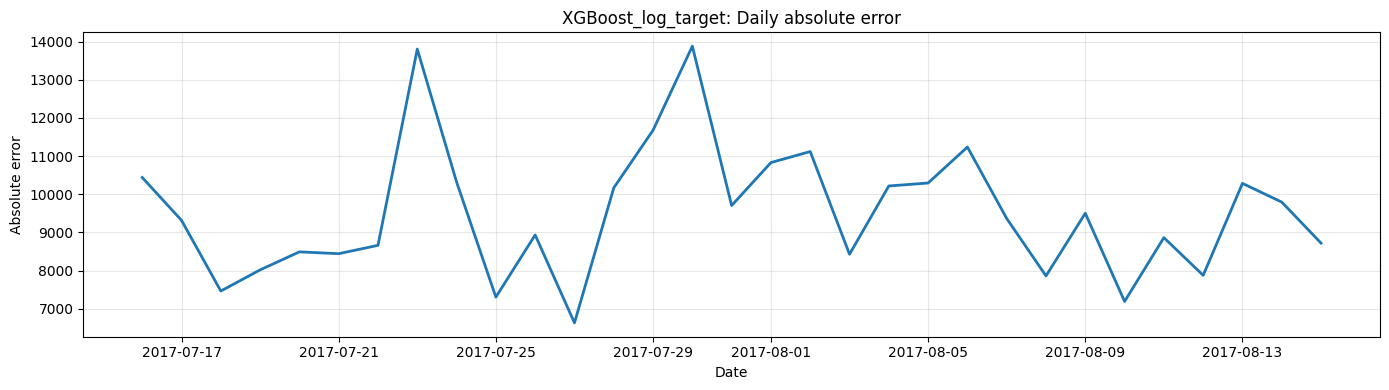

MODEL: LightGBM


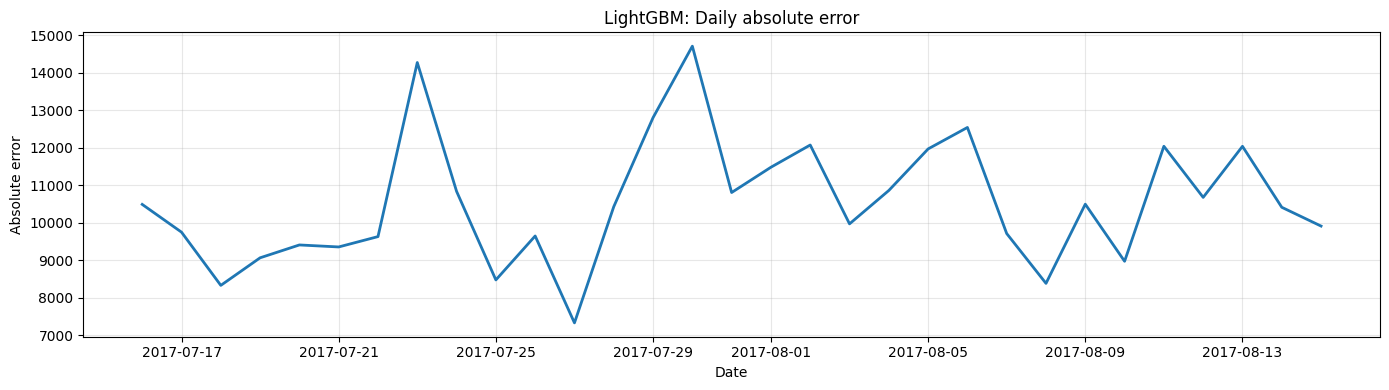

MODEL: LightGBM_log_target


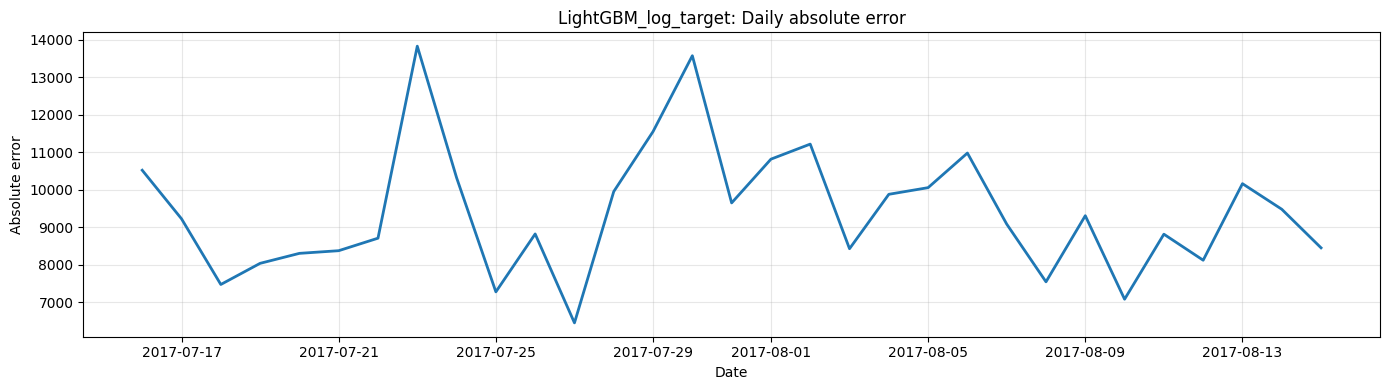

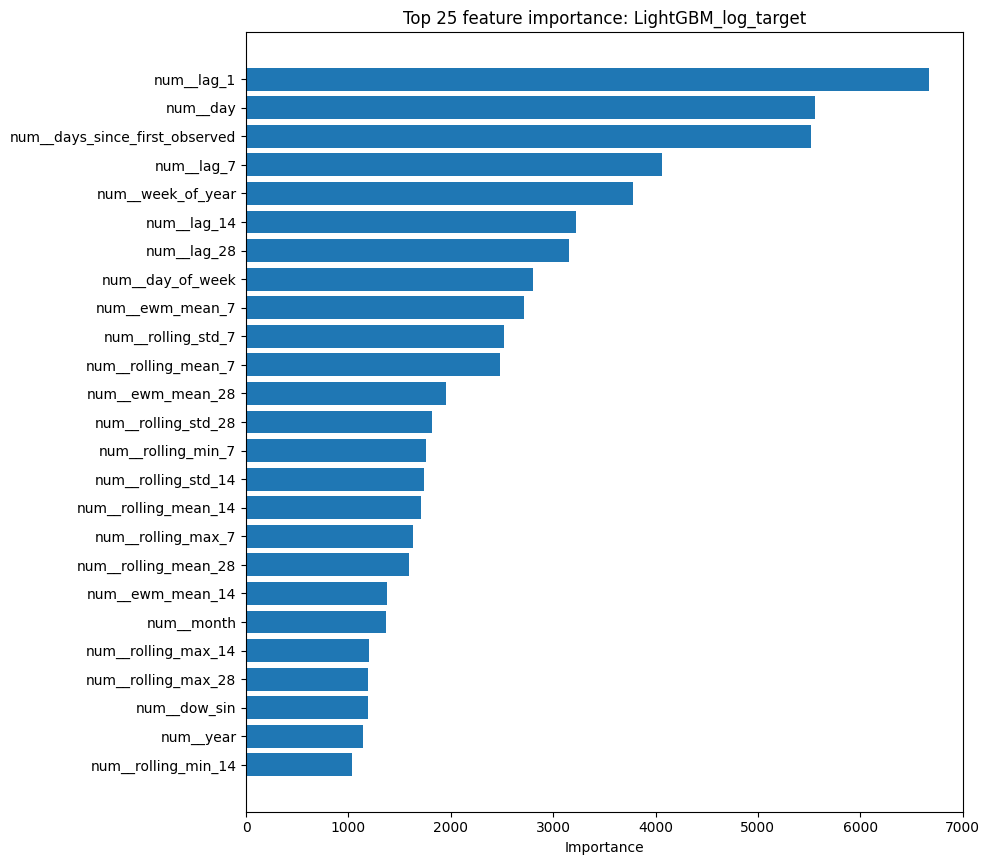

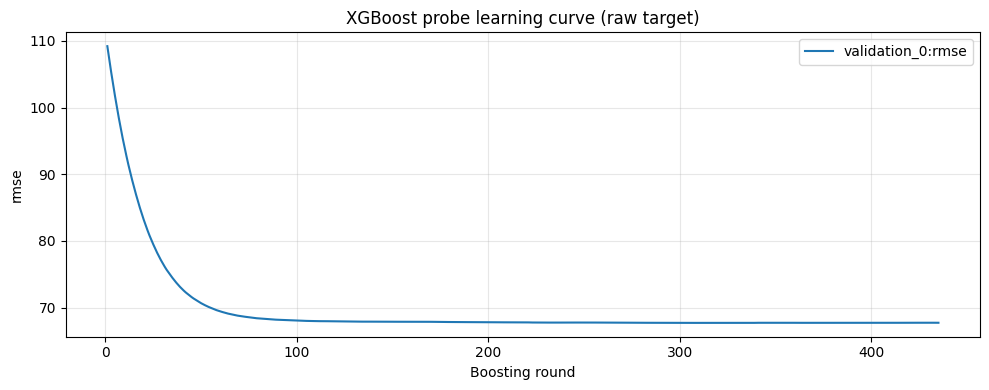

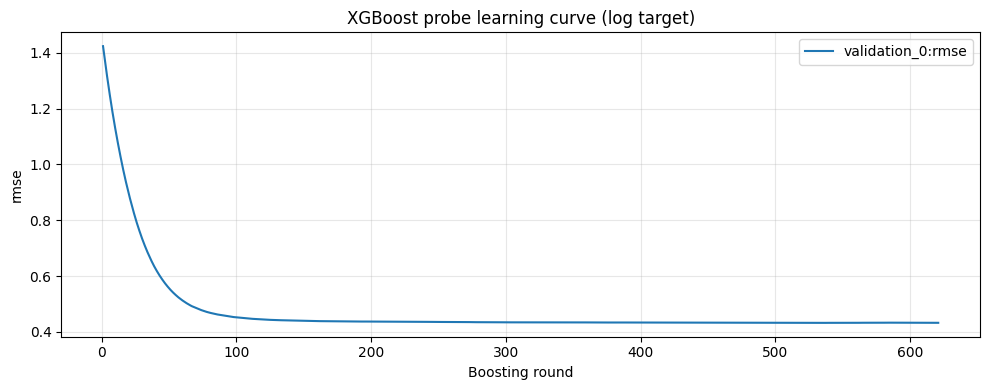

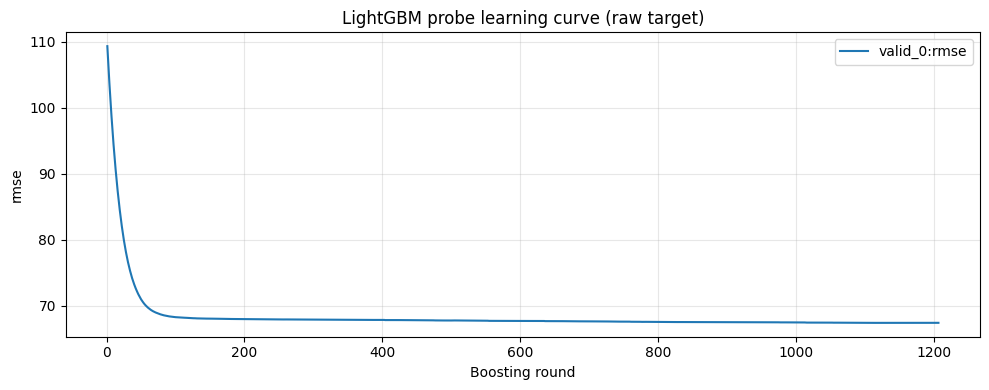

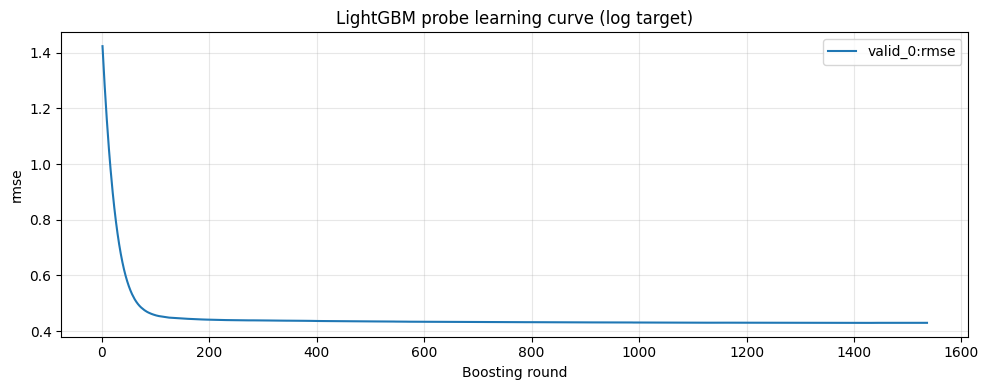

In [6]:
# ==========================================
# CELL 3: USEFUL DIAGNOSTIC PLOTS
# ==========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------------
# 0. SMALL HELPERS
# --------------------------------------------------
def get_eval_df_by_model(model_name):
    mapping = {
        "Lag7Baseline": lag7_eval_df,
        "RandomForest": rf_eval_df,
        "XGBoost": xgb_eval_df,
        "XGBoost_log_target": xgb_log_eval_df,
        "LightGBM": lgb_eval_df,
        "LightGBM_log_target": lgb_log_eval_df,
    }
    return mapping[model_name].copy()

def add_residual_cols(df, actual_col="sales_actual", pred_col="prediction"):
    out = df.copy()
    out["residual"] = out[actual_col] - out[pred_col]
    out["abs_error"] = np.abs(out["residual"])
    out["ape"] = np.where(
        np.abs(out[actual_col]) < 1e-9,
        np.nan,
        np.abs(out["residual"]) / np.abs(out[actual_col])
    )
    return out

def plot_bar_metric(train_df, test_df, metric, title=None, figsize=(12, 5)):
    merged = (
        train_df[["model", metric]].rename(columns={metric: "train"})
        .merge(
            test_df[["model", metric]].rename(columns={metric: "test"}),
            on="model",
            how="inner"
        )
        .sort_values("test", ascending=True)
        .reset_index(drop=True)
    )

    x = np.arange(len(merged))
    width = 0.38

    plt.figure(figsize=figsize)
    plt.bar(x - width/2, merged["train"], width=width, label="Train")
    plt.bar(x + width/2, merged["test"], width=width, label="Test")
    plt.xticks(x, merged["model"], rotation=25, ha="right")
    plt.ylabel(metric)
    plt.title(title or f"{metric}: Train vs Test")
    plt.legend()
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_single_bar(df, x_col, y_col, title, figsize=(12, 5), sort_ascending=True):
    plot_df = df[[x_col, y_col]].copy().sort_values(y_col, ascending=sort_ascending)
    plt.figure(figsize=figsize)
    plt.bar(plot_df[x_col], plot_df[y_col])
    plt.xticks(rotation=25, ha="right")
    plt.title(title)
    plt.ylabel(y_col)
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_time_series_eval(eval_df, model_name, top_n_items=5):
    tmp = add_residual_cols(eval_df)

    # daily total actual vs predicted
    daily = (
        tmp.groupby("date", as_index=False)[["sales_actual", "prediction", "abs_error"]]
        .sum()
        .sort_values("date")
    )

    plt.figure(figsize=(16, 5))
    plt.plot(daily["date"], daily["sales_actual"], label="Actual", linewidth=2)
    plt.plot(daily["date"], daily["prediction"], label="Predicted", linewidth=2)
    plt.title(f"{model_name}: Daily aggregated actual vs predicted")
    plt.xlabel("Date")
    plt.ylabel("Sales")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # daily abs error
    plt.figure(figsize=(16, 4))
    plt.plot(daily["date"], daily["abs_error"], linewidth=2)
    plt.title(f"{model_name}: Daily absolute error")
    plt.xlabel("Date")
    plt.ylabel("Absolute error")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # top hardest series by total abs error
    series_err = (
        tmp.groupby(["store_nbr", "item_nbr"], as_index=False)["abs_error"]
        .sum()
        .sort_values("abs_error", ascending=False)
        .head(top_n_items)
    )

    if not series_err.empty:
        fig, axes = plt.subplots(len(series_err), 1, figsize=(16, 4 * len(series_err)), sharex=False)
        if len(series_err) == 1:
            axes = [axes]

        for ax, (_, row) in zip(axes, series_err.iterrows()):
            s = int(row["store_nbr"])
            i = int(row["item_nbr"])
            one = tmp[(tmp["store_nbr"] == s) & (tmp["item_nbr"] == i)].sort_values("date")

            ax.plot(one["date"], one["sales_actual"], label="Actual", linewidth=2)
            ax.plot(one["date"], one["prediction"], label="Predicted", linewidth=2)
            ax.set_title(f"{model_name}: store={s}, item={i}, total abs error={row['abs_error']:.2f}")
            ax.grid(True, alpha=0.3)
            ax.legend()

        plt.tight_layout()
        plt.show()

def plot_actual_vs_pred_scatter(eval_df, model_name):
    tmp = add_residual_cols(eval_df)

    plt.figure(figsize=(7, 7))
    plt.scatter(tmp["sales_actual"], tmp["prediction"], alpha=0.15)
    max_val = float(max(tmp["sales_actual"].max(), tmp["prediction"].max()))
    plt.plot([0, max_val], [0, max_val], linestyle="--")
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(f"{model_name}: Actual vs Predicted")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_residual_diagnostics(eval_df, model_name):
    tmp = add_residual_cols(eval_df)

    # residual histogram
    plt.figure(figsize=(10, 5))
    plt.hist(tmp["residual"], bins=80)
    plt.title(f"{model_name}: Residual distribution (actual - predicted)")
    plt.xlabel("Residual")
    plt.ylabel("Frequency")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # residual vs predicted
    plt.figure(figsize=(10, 5))
    plt.scatter(tmp["prediction"], tmp["residual"], alpha=0.15)
    plt.axhline(0, linestyle="--")
    plt.title(f"{model_name}: Residual vs Predicted")
    plt.xlabel("Predicted")
    plt.ylabel("Residual")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # residual over time
    daily_res = (
        tmp.groupby("date", as_index=False)[["residual", "abs_error"]]
        .mean()
        .sort_values("date")
    )

    plt.figure(figsize=(16, 4))
    plt.plot(daily_res["date"], daily_res["residual"], linewidth=2)
    plt.axhline(0, linestyle="--")
    plt.title(f"{model_name}: Mean residual over time")
    plt.xlabel("Date")
    plt.ylabel("Mean residual")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_cumulative_error(eval_df, model_name):
    tmp = add_residual_cols(eval_df)
    daily = (
        tmp.groupby("date", as_index=False)["abs_error"]
        .sum()
        .sort_values("date")
    )
    daily["cum_abs_error"] = daily["abs_error"].cumsum()

    plt.figure(figsize=(16, 4))
    plt.plot(daily["date"], daily["cum_abs_error"], linewidth=2)
    plt.title(f"{model_name}: Cumulative absolute error")
    plt.xlabel("Date")
    plt.ylabel("Cumulative abs error")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_feature_importance_df(feat_imp_df, top_n=20, title="Feature importance"):
    if feat_imp_df is None or feat_imp_df.empty:
        print("No feature importance dataframe available.")
        return

    top = feat_imp_df.head(top_n).iloc[::-1]

    plt.figure(figsize=(10, max(6, top_n * 0.35)))
    plt.barh(top["feature"], top["importance"])
    plt.title(title)
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()

def try_plot_xgb_learning_curve(model, title):
    try:
        results = model.evals_result()
        if not results:
            print(f"No eval history available for {title}")
            return

        val_key = list(results.keys())[0]
        metric_key = list(results[val_key].keys())[0]
        vals = results[val_key][metric_key]

        plt.figure(figsize=(10, 4))
        plt.plot(range(1, len(vals) + 1), vals, label=f"{val_key}:{metric_key}")
        plt.title(title)
        plt.xlabel("Boosting round")
        plt.ylabel(metric_key)
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"Could not plot XGBoost learning curve for {title}: {e}")

def try_plot_lgb_learning_curve(model, title):
    try:
        results = getattr(model, "evals_result_", None)
        if not results:
            print(f"No eval history available for {title}")
            return

        first_dataset = list(results.keys())[0]
        first_metric = list(results[first_dataset].keys())[0]
        vals = results[first_dataset][first_metric]

        plt.figure(figsize=(10, 4))
        plt.plot(range(1, len(vals) + 1), vals, label=f"{first_dataset}:{first_metric}")
        plt.title(title)
        plt.xlabel("Boosting round")
        plt.ylabel(first_metric)
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"Could not plot LightGBM learning curve for {title}: {e}")


# --------------------------------------------------
# 1. OVERVIEW METRIC CHARTS
# --------------------------------------------------
plot_bar_metric(train_metrics_df, test_metrics_df, "RMSE", title="RMSE on Train vs Test")
plot_bar_metric(train_metrics_df, test_metrics_df, "MAE", title="MAE on Train vs Test")
plot_bar_metric(train_metrics_df, test_metrics_df, "WAPE", title="WAPE on Train vs Test")
plot_bar_metric(train_metrics_df, test_metrics_df, "SMAPE", title="SMAPE on Train vs Test")
plot_bar_metric(train_metrics_df, test_metrics_df, "R2", title="R² on Train vs Test")

plot_single_bar(gap_df, "model", "RMSE_gap", "Generalization gap: RMSE(test - train)", sort_ascending=False)
plot_single_bar(gap_df, "model", "MAE_gap", "Generalization gap: MAE(test - train)", sort_ascending=False)
plot_single_bar(gap_df, "model", "WAPE_gap", "Generalization gap: WAPE(test - train)", sort_ascending=False)
plot_single_bar(gap_df, "model", "R2_gap", "Generalization gap: R²(test - train)", sort_ascending=True)


# --------------------------------------------------
# 2. DAILY AGGREGATED FORECAST COMPARISON
# --------------------------------------------------
plt.figure(figsize=(18, 7))
plt.plot(daily_plot["date"], daily_plot["Actual"], label="Actual", linewidth=2)
for c in [col for col in daily_plot.columns if col not in ["date", "Actual"]]:
    plt.plot(daily_plot["date"], daily_plot[c], label=c, alpha=0.8)
plt.title("All models vs actual on daily aggregated horizon")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# --------------------------------------------------
# 3. BEST MODEL DEEP DIVE
# --------------------------------------------------
best_eval_df = get_eval_df_by_model(best_model_name)

plot_time_series_eval(best_eval_df, best_model_name, top_n_items=5)
plot_actual_vs_pred_scatter(best_eval_df, best_model_name)
plot_residual_diagnostics(best_eval_df, best_model_name)
plot_cumulative_error(best_eval_df, best_model_name)


# --------------------------------------------------
# 4. OPTIONAL: DIAGNOSTICS FOR ALL MODELS
# --------------------------------------------------
all_model_names = [
    "Lag7Baseline",
    "RandomForest",
    "XGBoost",
    "XGBoost_log_target",
    "LightGBM",
    "LightGBM_log_target",
]

for m in all_model_names:
    print("=" * 80)
    print("MODEL:", m)
    eval_df = get_eval_df_by_model(m)

    # daily abs error per model
    tmp = add_residual_cols(eval_df)
    daily_err = (
        tmp.groupby("date", as_index=False)["abs_error"]
        .sum()
        .sort_values("date")
    )

    plt.figure(figsize=(14, 4))
    plt.plot(daily_err["date"], daily_err["abs_error"], linewidth=2)
    plt.title(f"{m}: Daily absolute error")
    plt.xlabel("Date")
    plt.ylabel("Absolute error")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# --------------------------------------------------
# 5. FEATURE IMPORTANCE
# --------------------------------------------------
if "feat_imp" in globals() and feat_imp is not None:
    plot_feature_importance_df(feat_imp, top_n=25, title=f"Top 25 feature importance: {best_model_name}")


# --------------------------------------------------
# 6. LEARNING CURVES FROM EARLY-STOPPING PROBE MODELS
# --------------------------------------------------
# For XGBoost these usually exist via evals_result()
try_plot_xgb_learning_curve(xgb_probe_model, "XGBoost probe learning curve (raw target)")
try_plot_xgb_learning_curve(xgb_log_probe_model, "XGBoost probe learning curve (log target)")

# For LightGBM they usually exist in evals_result_
try_plot_lgb_learning_curve(lgb_probe_model, "LightGBM probe learning curve (raw target)")
try_plot_lgb_learning_curve(lgb_log_probe_model, "LightGBM probe learning curve (log target)")

In [7]:
# ==========================================
# SAVE ALL MODELS ARTIFACT PACKAGE
# ==========================================

import os
import sys
import json
import zipfile
import shutil
import platform
from pathlib import Path
from datetime import datetime, timezone

import joblib
import numpy as np
import pandas as pd
import sklearn
import xgboost
import lightgbm


# --------------------------------------------------
# 0. SAFETY CHECKS
# --------------------------------------------------
required_vars = [
    "train_ml",
    "future_ml",
    "valid_actuals_ml",
    "history_seed_ml",
    "preprocessor",
    "feature_cols",
    "categorical_feature_cols",
    "numeric_feature_cols",
    "q_low",
    "q_high",
    "best_model_name",
    "test_metrics_df",
    "train_metrics_df",
    "combined_metrics_df",
    "SELECTED_STORES",
    "COMMON_ITEMS_MODE",
    "SPLIT_DATE",
    "LAGS",
    "ROLLING_WINDOWS",
    "EWM_SPANS",
    "MAX_HISTORY",
    "USE_CURRENT_DAY_PROMOTION",
    "USE_PROMO_HISTORY_FEATURES",
    "USE_TRANSACTIONS_HISTORY_FEATURES",
    "USE_OIL_HISTORY_FEATURES",
    "USE_RETURN_HISTORY_FEATURES",
    "rf_model",
    "xgb_model",
    "xgb_log_model",
    "lgb_model",
    "lgb_log_model",
]

for v in required_vars:
    if v not in globals():
        raise ValueError(f"Missing required variable for export: {v}")


# --------------------------------------------------
# 1. MODEL REGISTRY
# --------------------------------------------------
SERIALIZABLE_MODEL_REGISTRY = {
    "RandomForest": {
        "model": rf_model,
        "target_mode": "raw",
        "family": "RandomForestRegressor",
    },
    "XGBoost": {
        "model": xgb_model,
        "target_mode": "raw",
        "family": "XGBRegressor",
    },
    "XGBoost_log_target": {
        "model": xgb_log_model,
        "target_mode": "log1p",
        "family": "XGBRegressor",
    },
    "LightGBM": {
        "model": lgb_model,
        "target_mode": "raw",
        "family": "LGBMRegressor",
    },
    "LightGBM_log_target": {
        "model": lgb_log_model,
        "target_mode": "log1p",
        "family": "LGBMRegressor",
    },
}

NON_SERIALIZABLE_STRATEGIES = {
    "Lag7Baseline": {
        "type": "rule_based_baseline",
        "description": "Uses lag_7 as forecast directly.",
        "target_mode": "raw",
    }
}

all_test_models_ranked = test_metrics_df["model"].tolist()
serializable_ranked_models = [m for m in all_test_models_ranked if m in SERIALIZABLE_MODEL_REGISTRY]

if not serializable_ranked_models:
    raise ValueError("No serializable fitted models available for export.")

default_serialized_model_name = serializable_ranked_models[0]

print("Best model on TEST:", best_model_name)
print("Default serialized model:", default_serialized_model_name)
print("Serializable models:", serializable_ranked_models)


# --------------------------------------------------
# 2. OUTPUT FOLDERS
# --------------------------------------------------
artifact_ts = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")
EXPORT_ROOT = Path(f"/kaggle/working/retail_forecast_artifacts_{artifact_ts}")

BUNDLE_DIR = EXPORT_ROOT / "bundle"
MODELS_DIR = BUNDLE_DIR / "models"
SCHEMA_DIR = EXPORT_ROOT / "schema"
METADATA_DIR = EXPORT_ROOT / "metadata"
RUNTIME_DIR = EXPORT_ROOT / "runtime"
TABLES_DIR = EXPORT_ROOT / "tables"
LOOKUPS_DIR = EXPORT_ROOT / "lookups"

if EXPORT_ROOT.exists():
    shutil.rmtree(EXPORT_ROOT)

for p in [BUNDLE_DIR, MODELS_DIR, SCHEMA_DIR, METADATA_DIR, RUNTIME_DIR, TABLES_DIR, LOOKUPS_DIR]:
    p.mkdir(parents=True, exist_ok=True)


# --------------------------------------------------
# 3. NORMALIZATION HELPERS
# --------------------------------------------------
def normalize_export_df(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    if "date" in out.columns:
        out["date"] = pd.to_datetime(out["date"])

    for c in ["store_nbr", "item_nbr"]:
        if c in out.columns:
            out[c] = pd.to_numeric(out[c], errors="coerce")
            if out[c].isna().any():
                bad = out[out[c].isna()].head(5)
                raise ValueError(f"Column {c} contains invalid values after coercion:\n{bad}")
            out[c] = out[c].astype(np.int64)

    return out


# --------------------------------------------------
# 4. EXPORT RUNTIME DATA
# --------------------------------------------------
history_seed_export = normalize_export_df(history_seed_ml)
future_base_export = normalize_export_df(future_ml)
valid_actuals_export = normalize_export_df(valid_actuals_ml)

history_seed_export.to_parquet(RUNTIME_DIR / "history_seed.parquet", index=False)
future_base_export.to_parquet(RUNTIME_DIR / "future_base_known.parquet", index=False)
valid_actuals_export.to_parquet(RUNTIME_DIR / "valid_actuals.parquet", index=False)


# --------------------------------------------------
# 5. LOOKUP TABLES
# --------------------------------------------------
eligible_pairs_df = (
    future_base_export[["store_nbr", "item_nbr"]]
    .drop_duplicates()
    .sort_values(["store_nbr", "item_nbr"])
    .reset_index(drop=True)
)

available_dates_df = (
    future_base_export[["date"]]
    .drop_duplicates()
    .sort_values(["date"])
    .reset_index(drop=True)
)

available_store_item_dates_df = (
    future_base_export[["date", "store_nbr", "item_nbr"]]
    .drop_duplicates()
    .sort_values(["date", "store_nbr", "item_nbr"])
    .reset_index(drop=True)
)

eligible_pairs_df.to_parquet(LOOKUPS_DIR / "eligible_store_item_pairs.parquet", index=False)
available_dates_df.to_parquet(LOOKUPS_DIR / "available_dates.parquet", index=False)
available_store_item_dates_df.to_parquet(LOOKUPS_DIR / "available_store_item_dates.parquet", index=False)


# --------------------------------------------------
# 6. FEATURE NAMES AFTER PREPROCESSING
# --------------------------------------------------
try:
    transformed_feature_names = list(preprocessor.get_feature_names_out())
except Exception:
    sample_input = train_ml[feature_cols].head(1).copy()
    if sample_input.empty:
        transformed_feature_names = [f"f_{i}" for i in range(len(feature_cols))]
    else:
        transformed_shape = preprocessor.transform(sample_input).shape[1]
        transformed_feature_names = [f"f_{i}" for i in range(transformed_shape)]


# --------------------------------------------------
# 7. SAVE TABLES
# --------------------------------------------------
train_metrics_df.to_csv(TABLES_DIR / "train_metrics.csv", index=False)
test_metrics_df.to_csv(TABLES_DIR / "test_metrics.csv", index=False)
combined_metrics_df.to_csv(TABLES_DIR / "train_test_metrics_comparison.csv", index=False)

# save a single leaderboard sorted by test RMSE/MAE
leaderboard_df = test_metrics_df.copy().sort_values(["RMSE", "MAE"]).reset_index(drop=True)
leaderboard_df.to_csv(TABLES_DIR / "leaderboard_test.csv", index=False)


# --------------------------------------------------
# 8. SAVE FEATURE IMPORTANCE FOR EACH FITTED MODEL
# --------------------------------------------------
feature_importance_index = []

for model_name, model_pack in SERIALIZABLE_MODEL_REGISTRY.items():
    model_obj = model_pack["model"]

    try:
        if hasattr(model_obj, "feature_importances_"):
            fi_df = pd.DataFrame({
                "feature": transformed_feature_names,
                "importance": model_obj.feature_importances_,
            }).sort_values("importance", ascending=False).reset_index(drop=True)

            fi_filename = f"feature_importance__{model_name}.csv"
            fi_df.to_csv(TABLES_DIR / fi_filename, index=False)

            feature_importance_index.append({
                "model_name": model_name,
                "file": f"tables/{fi_filename}",
                "rows": int(len(fi_df)),
            })
    except Exception as e:
        print(f"Skipping feature importance export for {model_name}: {e}")


# --------------------------------------------------
# 9. SAVE SCHEMA
# --------------------------------------------------
feature_schema = {
    "feature_cols": list(feature_cols),
    "categorical_feature_cols": list(categorical_feature_cols),
    "numeric_feature_cols": list(numeric_feature_cols),
    "id_columns": ["date", "store_nbr", "item_nbr"],
    "prediction_target_name": "sales",
    "available_serialized_models": serializable_ranked_models,
    "default_serialized_model": default_serialized_model_name,
}

with open(SCHEMA_DIR / "feature_schema.json", "w", encoding="utf-8") as f:
    json.dump(feature_schema, f, ensure_ascii=False, indent=2)

with open(SCHEMA_DIR / "transformed_feature_names.json", "w", encoding="utf-8") as f:
    json.dump(transformed_feature_names, f, ensure_ascii=False, indent=2)


# --------------------------------------------------
# 10. SAVE METADATA
# --------------------------------------------------
metrics_payload = {
    "original_best_model_name": str(best_model_name),
    "default_serialized_model_name": str(default_serialized_model_name),
    "available_serialized_models": serializable_ranked_models,
    "non_serializable_strategies": list(NON_SERIALIZABLE_STRATEGIES.keys()),
    "train_metrics": train_metrics_df.to_dict(orient="records"),
    "test_metrics": test_metrics_df.to_dict(orient="records"),
    "leaderboard_test": leaderboard_df.to_dict(orient="records"),
}

with open(METADATA_DIR / "metrics.json", "w", encoding="utf-8") as f:
    json.dump(metrics_payload, f, ensure_ascii=False, indent=2, default=str)

model_info = {
    "artifact_version": "2.0",
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "project_name": "retail-demand-forecasting",
    "original_best_model_name": str(best_model_name),
    "default_serialized_model_name": str(default_serialized_model_name),
    "available_serialized_models": serializable_ranked_models,
    "non_serializable_strategies": NON_SERIALIZABLE_STRATEGIES,
    "split_date": str(pd.Timestamp(SPLIT_DATE).date()),
    "selected_stores": [int(x) for x in SELECTED_STORES],
    "common_items_mode": str(COMMON_ITEMS_MODE),
    "top_n_common_items": int(TOP_N_COMMON_ITEMS) if "TOP_N_COMMON_ITEMS" in globals() else None,
    "feature_count": int(len(feature_cols)),
    "categorical_feature_count": int(len(categorical_feature_cols)),
    "numeric_feature_count": int(len(numeric_feature_cols)),
    "q_low": float(q_low),
    "q_high": float(q_high),
    "lags": [int(x) for x in LAGS],
    "rolling_windows": [int(x) for x in ROLLING_WINDOWS],
    "ewm_spans": [int(x) for x in EWM_SPANS],
    "max_history": int(MAX_HISTORY),
    "future_date_min": str(pd.to_datetime(future_base_export["date"]).min().date()),
    "future_date_max": str(pd.to_datetime(future_base_export["date"]).max().date()),
    "n_future_rows": int(len(future_base_export)),
    "n_history_seed_rows": int(len(history_seed_export)),
    "n_valid_actual_rows": int(len(valid_actuals_export)),
    "n_eligible_pairs": int(len(eligible_pairs_df)),
    "flags": {
        "use_current_day_promotion": bool(USE_CURRENT_DAY_PROMOTION),
        "use_promo_history_features": bool(USE_PROMO_HISTORY_FEATURES),
        "use_transactions_history_features": bool(USE_TRANSACTIONS_HISTORY_FEATURES),
        "use_oil_history_features": bool(USE_OIL_HISTORY_FEATURES),
        "use_return_history_features": bool(USE_RETURN_HISTORY_FEATURES),
    },
    "runtime_files": {
        "history_seed": "runtime/history_seed.parquet",
        "future_base_known": "runtime/future_base_known.parquet",
        "valid_actuals": "runtime/valid_actuals.parquet",
    },
    "lookup_files": {
        "eligible_store_item_pairs": "lookups/eligible_store_item_pairs.parquet",
        "available_dates": "lookups/available_dates.parquet",
        "available_store_item_dates": "lookups/available_store_item_dates.parquet",
    },
    "bundle_files": {
        "shared_bundle": "bundle/shared_bundle.joblib",
        "all_models_bundle": "bundle/all_models_bundle.joblib",
        "models_dir": "bundle/models/",
    },
    "feature_importance_files": feature_importance_index,
    "notes": [
        "Notebook functions are intentionally not serialized.",
        "Inference code should live in repository code.",
        "All fitted estimators are exported separately and together in a master bundle.",
        "Lag7Baseline is stored as metadata strategy, not as a fitted estimator object."
    ]
}

with open(METADATA_DIR / "model_info.json", "w", encoding="utf-8") as f:
    json.dump(model_info, f, ensure_ascii=False, indent=2)

library_versions = {
    "python": sys.version,
    "platform": platform.platform(),
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "scikit_learn": sklearn.__version__,
    "xgboost": xgboost.__version__,
    "lightgbm": lightgbm.__version__,
    "joblib": joblib.__version__,
}

with open(METADATA_DIR / "library_versions.json", "w", encoding="utf-8") as f:
    json.dump(library_versions, f, ensure_ascii=False, indent=2)


# --------------------------------------------------
# 11. SAVE SHARED BUNDLE
# --------------------------------------------------
shared_bundle = {
    "artifact_version": "2.0",
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "default_model_name": default_serialized_model_name,
    "available_model_names": serializable_ranked_models,
    "preprocessor": preprocessor,
    "feature_cols": list(feature_cols),
    "categorical_feature_cols": list(categorical_feature_cols),
    "numeric_feature_cols": list(numeric_feature_cols),
    "q_low": float(q_low),
    "q_high": float(q_high),
    "split_date": str(pd.Timestamp(SPLIT_DATE).date()),
    "lags": [int(x) for x in LAGS],
    "rolling_windows": [int(x) for x in ROLLING_WINDOWS],
    "ewm_spans": [int(x) for x in EWM_SPANS],
    "max_history": int(MAX_HISTORY),
    "flags": {
        "use_current_day_promotion": bool(USE_CURRENT_DAY_PROMOTION),
        "use_promo_history_features": bool(USE_PROMO_HISTORY_FEATURES),
        "use_transactions_history_features": bool(USE_TRANSACTIONS_HISTORY_FEATURES),
        "use_oil_history_features": bool(USE_OIL_HISTORY_FEATURES),
        "use_return_history_features": bool(USE_RETURN_HISTORY_FEATURES),
    },
}

joblib.dump(
    shared_bundle,
    BUNDLE_DIR / "shared_bundle.joblib",
    compress=3
)


# --------------------------------------------------
# 12. SAVE EACH MODEL SEPARATELY
# --------------------------------------------------
serialized_model_index = []

for model_name, model_pack in SERIALIZABLE_MODEL_REGISTRY.items():
    model_payload = {
        "artifact_version": "2.0",
        "created_utc": datetime.now(timezone.utc).isoformat(),
        "model_name": model_name,
        "target_mode": model_pack["target_mode"],
        "family": model_pack["family"],
        "model": model_pack["model"],
    }

    filename = f"{model_name}.joblib"
    joblib.dump(model_payload, MODELS_DIR / filename, compress=3)

    serialized_model_index.append({
        "model_name": model_name,
        "target_mode": model_pack["target_mode"],
        "family": model_pack["family"],
        "file": f"bundle/models/{filename}",
    })


# --------------------------------------------------
# 13. SAVE MASTER BUNDLE WITH ALL MODELS
# --------------------------------------------------
all_models_bundle = {
    "artifact_version": "2.0",
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "default_model_name": default_serialized_model_name,
    "available_model_names": serializable_ranked_models,
    "preprocessor": preprocessor,
    "feature_cols": list(feature_cols),
    "categorical_feature_cols": list(categorical_feature_cols),
    "numeric_feature_cols": list(numeric_feature_cols),
    "q_low": float(q_low),
    "q_high": float(q_high),
    "split_date": str(pd.Timestamp(SPLIT_DATE).date()),
    "lags": [int(x) for x in LAGS],
    "rolling_windows": [int(x) for x in ROLLING_WINDOWS],
    "ewm_spans": [int(x) for x in EWM_SPANS],
    "max_history": int(MAX_HISTORY),
    "flags": {
        "use_current_day_promotion": bool(USE_CURRENT_DAY_PROMOTION),
        "use_promo_history_features": bool(USE_PROMO_HISTORY_FEATURES),
        "use_transactions_history_features": bool(USE_TRANSACTIONS_HISTORY_FEATURES),
        "use_oil_history_features": bool(USE_OIL_HISTORY_FEATURES),
        "use_return_history_features": bool(USE_RETURN_HISTORY_FEATURES),
    },
    "models": {
        model_name: {
            "target_mode": model_pack["target_mode"],
            "family": model_pack["family"],
            "model": model_pack["model"],
        }
        for model_name, model_pack in SERIALIZABLE_MODEL_REGISTRY.items()
    },
    "non_serializable_strategies": NON_SERIALIZABLE_STRATEGIES,
}

joblib.dump(
    all_models_bundle,
    BUNDLE_DIR / "all_models_bundle.joblib",
    compress=3
)


# --------------------------------------------------
# 14. SAVE MODEL INDEX
# --------------------------------------------------
with open(METADATA_DIR / "serialized_model_index.json", "w", encoding="utf-8") as f:
    json.dump(serialized_model_index, f, ensure_ascii=False, indent=2)


# --------------------------------------------------
# 15. README
# --------------------------------------------------
readme_text = f"""
Retail Forecast Artifact Package
================================

Created UTC: {datetime.now(timezone.utc).isoformat()}

Contents
--------
bundle/shared_bundle.joblib
    Shared inference bundle:
    - fitted preprocessor
    - feature definitions
    - clip thresholds
    - recursive inference config
    - default model name
    - available model names

bundle/models/*.joblib
    One file per fitted model:
    - RandomForest
    - XGBoost
    - XGBoost_log_target
    - LightGBM
    - LightGBM_log_target

bundle/all_models_bundle.joblib
    Single master bundle containing:
    - shared preprocessing/config
    - all fitted estimators

schema/feature_schema.json
    Raw feature schema for inference.

schema/transformed_feature_names.json
    Feature names after preprocessing / OHE.

metadata/model_info.json
metadata/metrics.json
metadata/library_versions.json
metadata/serialized_model_index.json
    Human-readable metadata and reproducibility info.

runtime/history_seed.parquet
runtime/future_base_known.parquet
runtime/valid_actuals.parquet
    Runtime tables for known-horizon recursive forecasting.

lookups/eligible_store_item_pairs.parquet
lookups/available_dates.parquet
lookups/available_store_item_dates.parquet
    Tables for validating store/item/date requests.

tables/train_metrics.csv
tables/test_metrics.csv
tables/train_test_metrics_comparison.csv
tables/leaderboard_test.csv
tables/feature_importance__*.csv
    Exported evaluation and analysis tables.

Important
---------
Notebook Python functions are NOT serialized by design.
Keep inference logic in repository code and load only artifacts.
Lag7Baseline is saved as metadata strategy, not as a fitted estimator file.
""".strip()

with open(EXPORT_ROOT / "README.txt", "w", encoding="utf-8") as f:
    f.write(readme_text)


# --------------------------------------------------
# 16. ZIP EVERYTHING
# --------------------------------------------------
ZIP_PATH = Path(f"/kaggle/working/{EXPORT_ROOT.name}.zip")
if ZIP_PATH.exists():
    ZIP_PATH.unlink()

with zipfile.ZipFile(ZIP_PATH, "w", compression=zipfile.ZIP_DEFLATED) as zf:
    for file_path in EXPORT_ROOT.rglob("*"):
        if file_path.is_file():
            zf.write(file_path, arcname=file_path.relative_to(EXPORT_ROOT))


# --------------------------------------------------
# 17. SMOKE TEST
# --------------------------------------------------
loaded_shared_bundle = joblib.load(BUNDLE_DIR / "shared_bundle.joblib")
loaded_all_models_bundle = joblib.load(BUNDLE_DIR / "all_models_bundle.joblib")

print("Loaded shared bundle default model :", loaded_shared_bundle["default_model_name"])
print("Loaded shared bundle models        :", loaded_shared_bundle["available_model_names"])
print("Loaded all-model bundle models     :", list(loaded_all_models_bundle["models"].keys()))
print("Future date min                    :", model_info["future_date_min"])
print("Future date max                    :", model_info["future_date_max"])
print("Eligible pairs count               :", model_info["n_eligible_pairs"])
print("ZIP created                        :", ZIP_PATH)
print("EXPORT ROOT                        :", EXPORT_ROOT)

Best model on TEST: LightGBM_log_target
Default serialized model: LightGBM_log_target
Serializable models: ['LightGBM_log_target', 'XGBoost_log_target', 'RandomForest', 'LightGBM', 'XGBoost']
Loaded shared bundle default model : LightGBM_log_target
Loaded shared bundle models        : ['LightGBM_log_target', 'XGBoost_log_target', 'RandomForest', 'LightGBM', 'XGBoost']
Loaded all-model bundle models     : ['RandomForest', 'XGBoost', 'XGBoost_log_target', 'LightGBM', 'LightGBM_log_target']
Future date min                    : 2017-07-16
Future date max                    : 2017-08-15
Eligible pairs count               : 500
ZIP created                        : /kaggle/working/retail_forecast_artifacts_20260322T220131Z.zip
EXPORT ROOT                        : /kaggle/working/retail_forecast_artifacts_20260322T220131Z
